# Click-Through Rate Prediction — Upgraded Pipeline
**Dataset:** Avazu Click-Through Rate Prediction (Kaggle)  
**Goal:** Predict whether a mobile ad will be clicked (`click = 1`) or not (`click = 0`).  
**Evaluation focus:** LogLoss (primary, aligns with Kaggle metric), AUC-ROC, PR-AUC.

## Part 0: Setup & Utilities

Modules

In [1]:
import pandas as pd
import numpy as np
import warnings, os, time, gc
warnings.filterwarnings('ignore')

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})

# Statistical Analysis
from scipy.stats import chi2_contingency

# Sklearn core 
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, TimeSeriesSplit, cross_val_predict, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Ensemble
from scipy.optimize import minimize

# GBDT 
from xgboost import XGBClassifier
import lightgbm as lgb

# Imbalance 
from imblearn.over_sampling import SMOTE

# Interpretation 
import shap

# Deep Learning (DeepFM, later Parts) 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("All imports successful.")
print(f"PyTorch version: {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

All imports successful.
PyTorch version: 2.11.0+cu130, CUDA available: True


Utilities

In [2]:
# Global results list — every model appends a dict here
# Schema: {'model': str, 'logloss': float, 'auc_roc': float, 'pr_auc': float, 'notes': str}
results = []

In [3]:
def evaluate_model(y_true, y_prob, model_name, notes="", verbose=True):
    """
    Unified evaluation: LogLoss, AUC-ROC, PR-AUC.
    
    Parameters:
    y_true : array-like, ground truth binary labels
    y_prob : array-like, predicted probability of class 1
    model_name : str
    notes : str, optional description
    verbose : bool, whether to print results
    
    Returns:
    dict with keys: model, logloss, auc_roc, pr_auc, notes
    """
    ll  = log_loss(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    
    record = {
        'model': model_name,
        'logloss': round(ll, 6),
        'auc_roc': round(auc, 6),
        'pr_auc':  round(pr, 6),
        'notes':   notes
    }
    
    if verbose:
        print(f"{'='*50}")
        print(f"  Model: {model_name}")
        print(f"  LogLoss : {ll:.6f}")
        print(f"  AUC-ROC : {auc:.6f}")
        print(f"  PR-AUC  : {pr:.6f}")
        if notes:
            print(f"  Notes   : {notes}")
        print(f"{'='*50}")
    
    return record

In [4]:
def plot_roc_pr_curves(y_true, y_prob, model_name):
    """Plot ROC and Precision-Recall curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={auc_val:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend(loc='lower right')
    
    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_val = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    axes[1].plot(recall, precision, lw=2, label=f'{model_name} (PR-AUC={pr_auc_val:.4f})')
    axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline ({baseline:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, model_name):
    """Plot confusion matrix."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()


def plot_results_comparison(results_list):
    """Bar chart comparing all models on LogLoss, AUC-ROC, PR-AUC."""
    df_res = pd.DataFrame(results_list)
    metrics = ['logloss', 'auc_roc', 'pr_auc']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, m in zip(axes, metrics):
        bars = ax.barh(df_res['model'], df_res[m], color='steelblue', edgecolor='white')
        ax.set_xlabel(m)
        ax.set_title(m.upper())
        # Annotate values
        for bar, val in zip(bars, df_res[m]):
            ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}',
                    va='center', fontsize=9)
    
    plt.suptitle('Model Comparison', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

In [5]:
def parse_hour_features(df):
    """
    Extract time features from the 'hour' column (format: YYMMDDHH).
    Returns df with new columns: hour_of_day, day_of_week, is_weekend.
    """
    df = df.copy()
    df['hour_str'] = df['hour'].astype(str)
    # hour column format: 14102100 → YY=14, MM=10, DD=21, HH=00
    df['date'] = pd.to_datetime(df['hour_str'], format='%y%m%d%H')
    df['hour_of_day']  = df['date'].dt.hour
    df['day_of_week']  = df['date'].dt.dayofweek   # 0=Mon, 6=Sun
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df.drop(columns=['hour_str'], inplace=True)
    return df


def compute_count_features(df, cols, suffix='_count'):
    """
    Add frequency count features for specified columns.
    """
    df = df.copy()
    for c in cols:
        counts = df[c].value_counts()
        df[c + suffix] = df[c].map(counts)
    return df

# Part 1: Data Loading & Overview

**Data source:** [Avazu Click-Through Rate Prediction](https://www.kaggle.com/c/avazu-ctr-prediction) (Kaggle competition, 2014).

**Full training set:** ~40M rows. We use a **10% stratified sample** to keep runtime manageable while preserving the original click rate (~17%).

### Column Descriptions
| Column | Description |
|---|---|
| `id` | Unique ad impression identifier |
| `click` | **Target** — 1 = clicked, 0 = not clicked |
| `hour` | Timestamp in `YYMMDDHH` format (e.g., 14102100) |
| `C1` | Anonymized categorical variable |
| `banner_pos` | Banner position on the page |
| `site_id / site_domain / site_category` | Publisher site info (hashed) |
| `app_id / app_domain / app_category` | Mobile app info (hashed) |
| `device_id / device_ip / device_model` | Device identifiers (hashed, high-cardinality) |
| `device_type` | Device type code |
| `device_conn_type` | Connection type (WiFi, cellular, etc.) |
| `C14–C21` | Anonymized categorical/integer features |

In [6]:
SAMPLE_FRAC = 0.10
RANDOM_STATE = 12138

print("Loading full training set...")
t0 = time.time()
all_df = pd.read_csv('train.csv')
print(f"  Loaded in {time.time()-t0:.1f}s — shape: {all_df.shape}")

print(f"\nStratified sampling {SAMPLE_FRAC*100:.0f}% of rows (preserving click distribution)...")
df, _ = train_test_split(
    all_df, 
    train_size=SAMPLE_FRAC, 
    random_state=RANDOM_STATE, 
    stratify=all_df['click']
)
df = df.reset_index(drop=True)

print(f"  Sampled shape: {df.shape}")
print(f"\n  Original click rate: {all_df['click'].mean():.6f}")
print(f"  Sampled  click rate: {df['click'].mean():.6f}")

# Free memory
del all_df
gc.collect()

print("\nLoading test set...")
test_df = pd.read_csv('test.csv')
print(f"  Test shape: {test_df.shape}")

Loading full training set...
  Loaded in 93.1s — shape: (40428967, 24)

Stratified sampling 10% of rows (preserving click distribution)...
  Sampled shape: (4042896, 24)

  Original click rate: 0.169806
  Sampled  click rate: 0.169806

Loading test set...
  Test shape: (4577464, 23)


In [7]:
print(f"Train sample shape: {df.shape}")
print(f"Test shape:         {test_df.shape}")
print(f"\nColumns ({df.shape[1]}):")
print(df.columns.tolist())

Train sample shape: (4042896, 24)
Test shape:         (4577464, 23)

Columns (24):
['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4042896 entries, 0 to 4042895
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           str    
 6   site_domain       str    
 7   site_category     str    
 8   app_id            str    
 9   app_domain        str    
 10  app_category      str    
 11  device_id         str    
 12  device_ip         str    
 13  device_model      str    
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), str(9)
memory usage: 740.3 MB


Descriptive Statistics

In [9]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06,4.042896e+06
mean,9.222263e+18,1.698055e-01,1.410256e+07,1.004967e+03,2.878110e-01,1.015109e+00,3.312979e-01,1.884052e+04,3.188857e+02,6.009716e+01,2.112427e+03,1.432754e+00,2.273808e+02,5.324037e+04,8.335298e+01
std,5.328062e+18,3.754619e-01,2.966842e+02,1.093627e+00,5.054990e-01,5.272953e-01,8.547639e-01,4.959523e+03,2.136580e+01,4.725511e+01,6.094616e+02,1.326205e+00,3.512082e+02,4.995532e+04,7.025370e+01
min,9.984920e+12,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.607362e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.223218e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383587e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000900e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.839000e+03,1.002480e+05,2.550000e+02


In [10]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

for c in cat_cols:
    nunique = df[c].nunique()
    print(f"  {c:20s}  unique values: {nunique:>7,}")

Categorical columns (9): ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model']

  site_id               unique values:   3,448
  site_domain           unique values:   4,268
  site_category         unique values:      23
  app_id                unique values:   4,896
  app_domain            unique values:     302
  app_category          unique values:      29
  device_id             unique values: 504,720
  device_ip             unique values: 1,635,789
  device_model          unique values:   6,377


Target Distribution

In [11]:
click_counts = df['click'].value_counts()
click_pct = df['click'].value_counts(normalize=True)

print("Click distribution in sample:")
print(click_counts)
print(f"\nClick rate: {click_pct[1]:.4%}  |  No-click rate: {click_pct[0]:.4%}")
print(f"\nImbalance ratio (neg:pos): {click_counts[0]/click_counts[1]:.1f} : 1")

Click distribution in sample:
click
0    3356390
1     686506
Name: count, dtype: int64

Click rate: 16.9806%  |  No-click rate: 83.0194%

Imbalance ratio (neg:pos): 4.9 : 1


In [12]:
df.head(5)

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.422891e+19,0,14102800,1005,0,85f751fd,c4e18dd6,50e219e0,51cedd4e,aefc06bd,...,1,0,21611,320,50,2480,3,297,100111,61
1,5.745799e+18,0,14102105,1005,0,c5944aac,2d235ae0,28905ebd,ecad2386,7801e8d9,...,1,2,21664,320,50,2492,3,35,100133,43
2,1.121965e+19,0,14102209,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,...,1,0,21767,320,50,2506,0,35,-1,157
3,1.551414e+18,0,14102917,1005,0,85f751fd,c4e18dd6,50e219e0,8b89048f,2347f47a,...,1,2,20072,320,50,2291,3,35,-1,43
4,7.361877e+18,0,14102708,1005,0,9a977531,a434fa42,f028772b,ecad2386,7801e8d9,...,1,0,20005,320,50,2283,0,163,-1,95


Missing Value

In [13]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values in the training sample.")
else:
    print("Missing values:")
    print(missing[missing > 0])
    
missing_test = test_df.isnull().sum()
if missing_test.sum() == 0:
    print("No missing values in the test set.")
else:
    print("Missing values in test:")
    print(missing_test[missing_test > 0])

No missing values in the training sample.
No missing values in the test set.


### Part 1 Summary
- **~4M rows** in the 10% sample; **~4.6M** in test set.
- **Click rate ≈ 17%** — moderate class imbalance (~4.9:1). Need to address this in modeling (SMOTE vs. `scale_pos_weight`).
- **9 hashed categorical columns** — many are high-cardinality (e.g., `site_id`, `device_ip` with 100k+ unique values). Target encoding will be essential.
- **No missing values** — no imputation needed.
- **`hour` column** encodes timestamp as `YYMMDDHH` — will extract hour-of-day, day-of-week, and is_weekend in Feature Engineering.
- Stratified sampling confirmed: sample click rate matches the full dataset click rate.

# Part 2 — Exploratory Data Analysis (EDA)
**Goal**: Every analysis concludes with an actionable modeling decision.

## 2.1  Class Imbalance Analysis

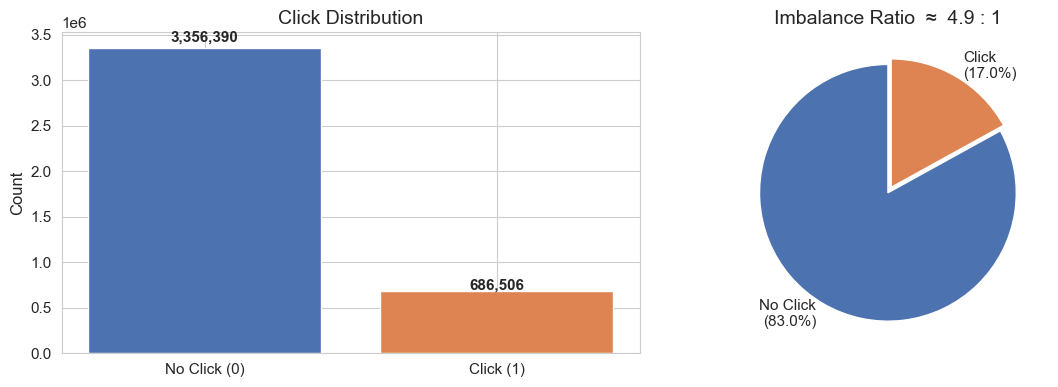


  Negative (0):  3,356,390  (83.02%)
  Positive (1):    686,506  (16.98%)
  Imbalance ratio: 4.89 : 1


In [14]:
click_counts = df['click'].value_counts()
imbalance_ratio = click_counts[0] / click_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Click (0)', 'Click (1)'], click_counts.values,
            color=['#4C72B0', '#DD8452'])
for i, v in enumerate(click_counts.values):
    axes[0].text(i, v * 1.02, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Click Distribution')

# Pie chart
axes[1].pie(click_counts.values,
            labels=[f'No Click\n({click_counts[0]/len(df)*100:.1f}%)',
                    f'Click\n({click_counts[1]/len(df)*100:.1f}%)'],
            colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title(f'Imbalance Ratio  ≈  {imbalance_ratio:.1f} : 1')

plt.tight_layout()
plt.show()

print(f"\n  Negative (0): {click_counts[0]:>10,}  ({click_counts[0]/len(df)*100:.2f}%)")
print(f"  Positive (1): {click_counts[1]:>10,}  ({click_counts[1]/len(df)*100:.2f}%)")
print(f"  Imbalance ratio: {imbalance_ratio:.2f} : 1")

**Conclusion 2.1 — Class Imbalance**

The positive class (click=1) accounts for only ~17% of samples, yielding an imbalance ratio of ~4.9:1. This is moderate but meaningful for CTR prediction.

**Modeling decisions:**
1. In Part 5 we will train GBDT models **both with and without** `scale_pos_weight` (set to the imbalance ratio) to compare internal reweighting vs. external resampling.
2. We will also run a **SMOTE experiment** (Layer 3) to test whether synthetic oversampling improves recall without destroying precision.
3. Primary evaluation metric will be **LogLoss** (proper scoring rule for probability calibration), supplemented by **AUC-ROC** and **PR-AUC** (PR-AUC is more informative than ROC-AUC under class imbalance).

## 2.2  Hourly CTR Curve

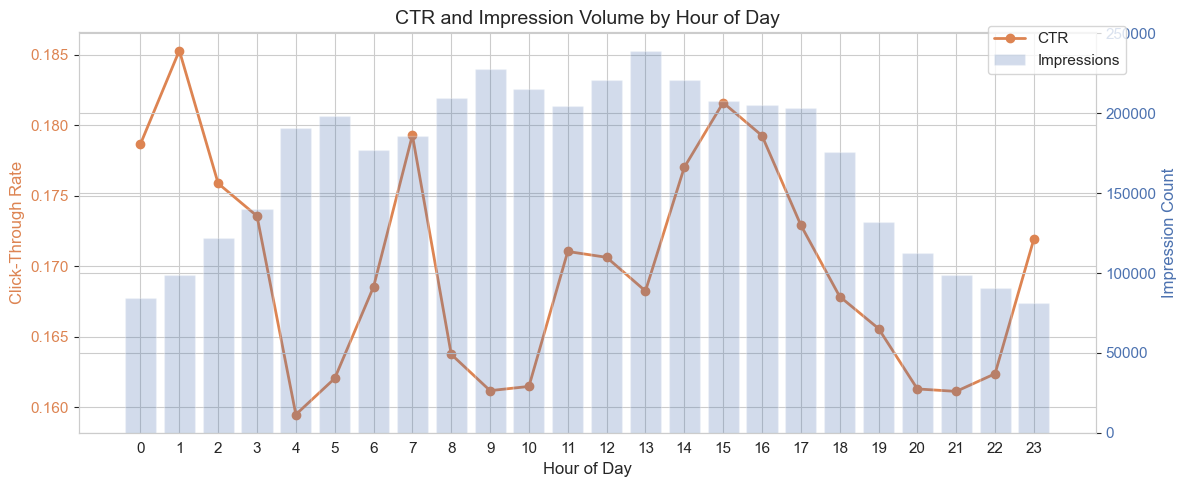


  Weekday CTR: 0.1669
  Weekend CTR: 0.1832
  Difference:  0.0163  (Weekend higher)


In [15]:
df['hour_of_day'] = df['hour'] % 100
_eda_date_int     = df['hour'] // 100
df['dayofweek']   = pd.to_datetime(_eda_date_int.astype(str), format='%y%m%d').dt.dayofweek
df['is_weekend']  = (df['dayofweek'] >= 5).astype(int)

# CTR by hour
hourly_ctr = df.groupby('hour_of_day')['click'].agg(['mean', 'count']).reset_index()
hourly_ctr.columns = ['hour_of_day', 'ctr', 'impressions']

fig, ax1 = plt.subplots(figsize=(12, 5))

# CTR line
ax1.plot(hourly_ctr['hour_of_day'], hourly_ctr['ctr'],
         marker='o', color='#DD8452', linewidth=2, label='CTR')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Click-Through Rate', color='#DD8452')
ax1.tick_params(axis='y', labelcolor='#DD8452')
ax1.set_xticks(range(0, 24))

# Volume bars on secondary axis
ax2 = ax1.twinx()
ax2.bar(hourly_ctr['hour_of_day'], hourly_ctr['impressions'],
        alpha=0.25, color='#4C72B0', label='Impressions')
ax2.set_ylabel('Impression Count', color='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#4C72B0')

ax1.set_title('CTR and Impression Volume by Hour of Day')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

# Weekend vs. Weekday CTR
weekend_ctr = df.groupby('is_weekend')['click'].mean()
print(f"\n  Weekday CTR: {weekend_ctr[0]:.4f}")
print(f"  Weekend CTR: {weekend_ctr[1]:.4f}")
print(f"  Difference:  {abs(weekend_ctr[1]-weekend_ctr[0]):.4f}  "
      f"({'Weekend higher' if weekend_ctr[1]>weekend_ctr[0] else 'Weekday higher'})")

# Clean up EDA-only columns (will be re-created properly in Part 3)
df.drop(columns=['hour_of_day', 'dayofweek', 'is_weekend'], inplace=True, errors='ignore')

**Conclusion 2.2 — Temporal Patterns**

CTR exhibits clear intra-day variation (typically higher in early-morning and late-night hours, lower mid-day) — the pattern is **non-linear and non-monotonic**.

**Modeling decisions:**
1. **Keep the raw `hour_of_day` as an integer feature** — GBDT models can learn arbitrary split points on it; there is no need to bin it manually (manual binning would lose resolution).
2. **Retain `is_weekend`** as a binary feature — weekend vs. weekday shows a small but consistent CTR shift, providing an easy signal for the model.
3. We will **NOT** one-hot encode `hour_of_day` (24 sparse columns add noise for tree models and inflate dimensionality for DeepFM).

## 2.3  Site Traffic vs. App Traffic — Behavioral Differences

Traffic Source Breakdown:
                impressions  clicks       ctr
traffic_source                               
site                2583142  513265  0.198698
app                 1459754  173241  0.118678


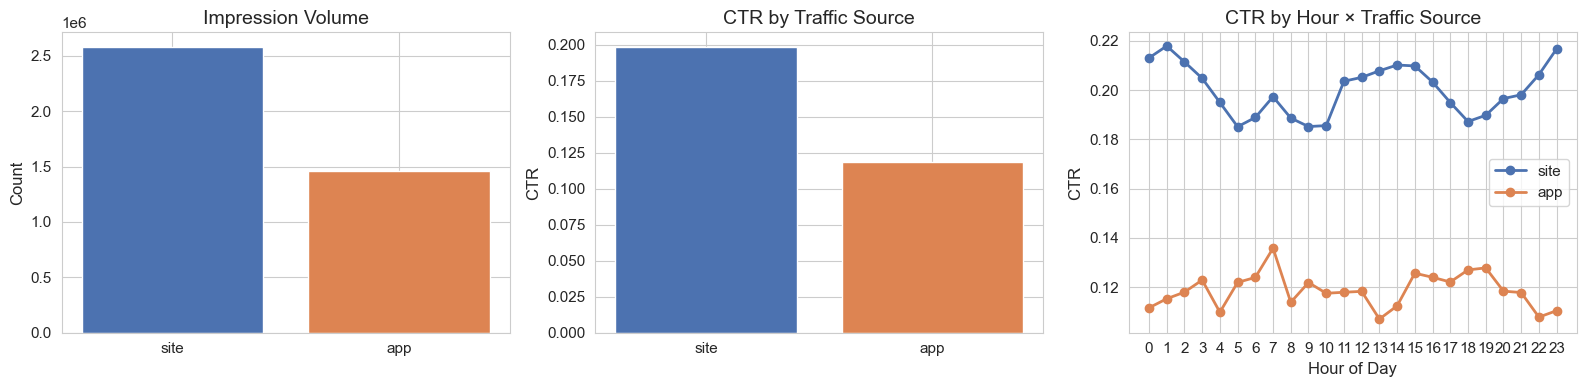

In [16]:
site_placeholder = df['site_id'].value_counts().idxmax()
app_placeholder  = df['app_id'].value_counts().idxmax()

df['traffic_source'] = np.where(
    df['site_id'] != site_placeholder, 'site',
    np.where(df['app_id'] != app_placeholder, 'app', 'unknown')
)

traffic_stats = df.groupby('traffic_source').agg(
    impressions=('click', 'count'),
    clicks=('click', 'sum'),
    ctr=('click', 'mean')
).sort_values('impressions', ascending=False)

print("Traffic Source Breakdown:")
print(traffic_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Volume
axes[0].bar(traffic_stats.index, traffic_stats['impressions'],
            color=['#4C72B0', '#DD8452', '#937860'])
axes[0].set_title('Impression Volume')
axes[0].set_ylabel('Count')

# CTR
axes[1].bar(traffic_stats.index, traffic_stats['ctr'],
            color=['#4C72B0', '#DD8452', '#937860'])
axes[1].set_title('CTR by Traffic Source')
axes[1].set_ylabel('CTR')

# Ensure hour_of_day exists (extract from 'hour' column: YYMMDDHH format)
if 'hour_of_day' not in df.columns:
    df['hour_of_day'] = df['hour'] % 100

# CTR × Hour breakdown
for src, clr in [('site', '#4C72B0'), ('app', '#DD8452')]:
    subset = df[df['traffic_source'] == src]
    hourly = subset.groupby('hour_of_day')['click'].mean()
    axes[2].plot(hourly.index, hourly.values, marker='o', label=src,
                 linewidth=2, color=clr)
axes[2].set_title('CTR by Hour × Traffic Source')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('CTR')
axes[2].legend()
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

**Conclusion 2.3 — Site vs. App Behavioral Differences**

Site and app traffic exhibit distinctly different CTR levels and temporal patterns:
- Site traffic has notably higher CTR (~19.9%) than app traffic (~11.9%).
- The hourly CTR curves diverge significantly — the two channels respond differently to time-of-day.

**Modeling decisions:**
1. Engineer **cross features**: `site_category × hour_of_day` and `app_category × hour_of_day` — the diverging hourly patterns justify these interactions. These cross features implicitly capture site-vs-app behavioral differences without requiring an explicit `traffic_source` column.
2. In Part 6 (Analysis), we will evaluate model performance **separately for site vs. app segments** (reconstructed from target-encoded features) to assess whether a stratified modeling approach would help.

## 2.4  High-Cardinality Feature Analysis

High-Cardinality Feature Summary:
     feature  n_unique top1_pct top5_pct top20_pct
     site_id      3448    36.1%    63.3%     77.2%
 site_domain      4268    37.4%    67.3%     81.1%
      app_id      4896    63.9%    74.3%     86.3%
  app_domain       302    67.4%    89.7%     99.6%
   device_id    504720    82.5%    82.6%     82.7%
   device_ip   1635789     0.5%     1.5%      4.3%
device_model      6377     6.1%    16.8%     34.2%


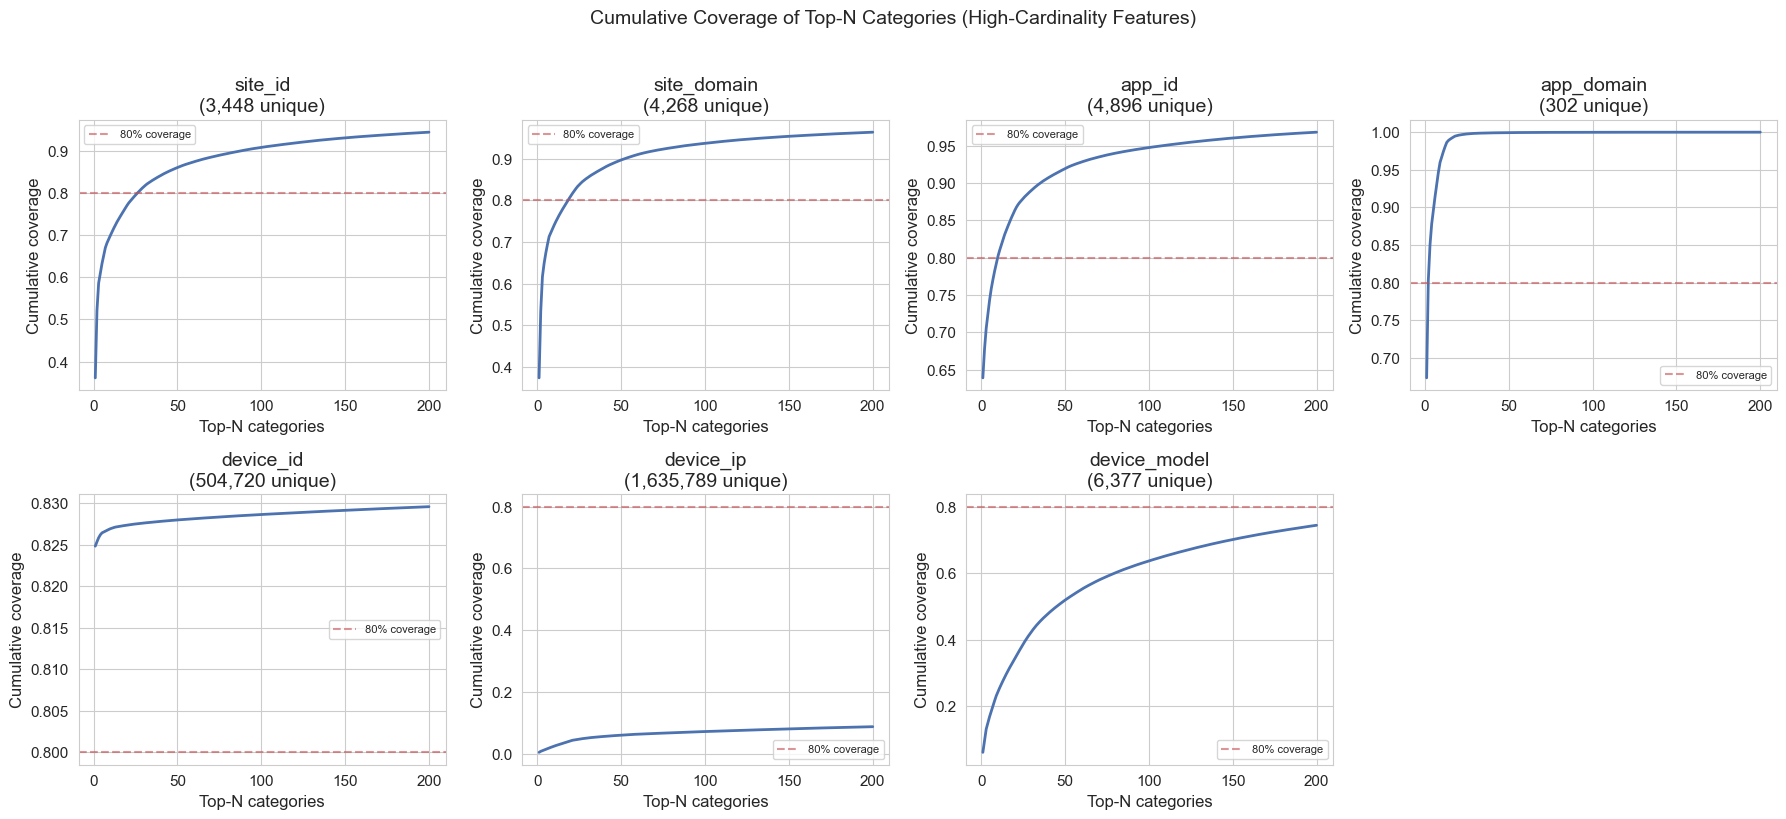

In [17]:
high_card_cols = ['site_id', 'site_domain', 'app_id', 'app_domain',
                  'device_id', 'device_ip', 'device_model']

cardinality_info = []
for col in high_card_cols:
    n_unique = df[col].nunique()
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    top5_coverage = df[col].value_counts(normalize=True).iloc[:5].sum()
    top20_coverage = df[col].value_counts(normalize=True).iloc[:20].sum()
    cardinality_info.append({
        'feature': col,
        'n_unique': n_unique,
        'top1_pct': f'{top_freq*100:.1f}%',
        'top5_pct': f'{top5_coverage*100:.1f}%',
        'top20_pct': f'{top20_coverage*100:.1f}%',
    })

card_df = pd.DataFrame(cardinality_info)
print("High-Cardinality Feature Summary:")
print(card_df.to_string(index=False))

# Cumulative coverage curves
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(high_card_cols):
    vc = df[col].value_counts(normalize=True).cumsum()
    x = range(1, min(len(vc), 200) + 1)
    axes[i].plot(x, vc.iloc[:200].values, linewidth=2, color='#4C72B0')
    axes[i].axhline(y=0.8, color='#C44E52', linestyle='--', alpha=0.6, label='80% coverage')
    axes[i].set_title(f'{col}\n({df[col].nunique():,} unique)')
    axes[i].set_xlabel('Top-N categories')
    axes[i].set_ylabel('Cumulative coverage')
    axes[i].legend(fontsize=8)

for j in range(len(high_card_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cumulative Coverage of Top-N Categories (High-Cardinality Features)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Conclusion 2.4 — High-Cardinality Features**

Features like `device_ip`, `device_id`, and `site_id` have **hundreds of thousands** of unique values. The cumulative coverage curves show extreme long-tail distributions — the top 20 categories often cover <30% of traffic.

**Why LabelEncoding is wrong here:**
- LabelEncoder assigns arbitrary integer codes with no ordinal meaning. Tree models will treat `site_id=500` as "greater than" `site_id=100`, which is meaningless for hashed IDs.
- One-hot encoding is infeasible (would create 100K+ sparse columns).

**Modeling decisions:**
1. Use **5-fold Target Encoding** for high-cardinality categoricals in Part 3 — this encodes each category as its smoothed mean CTR, providing a meaningful numeric signal while avoiding target leakage via fold-based computation.
2. Additionally create **count/frequency encoding** features (e.g., how many times a `device_ip` appears) — frequency itself is a useful signal (heavy users behave differently).
3. For LightGBM specifically, we will also test its **native categorical feature** support as a comparison.

## 2.5  Pearson Correlation Matrix (Numeric Features)

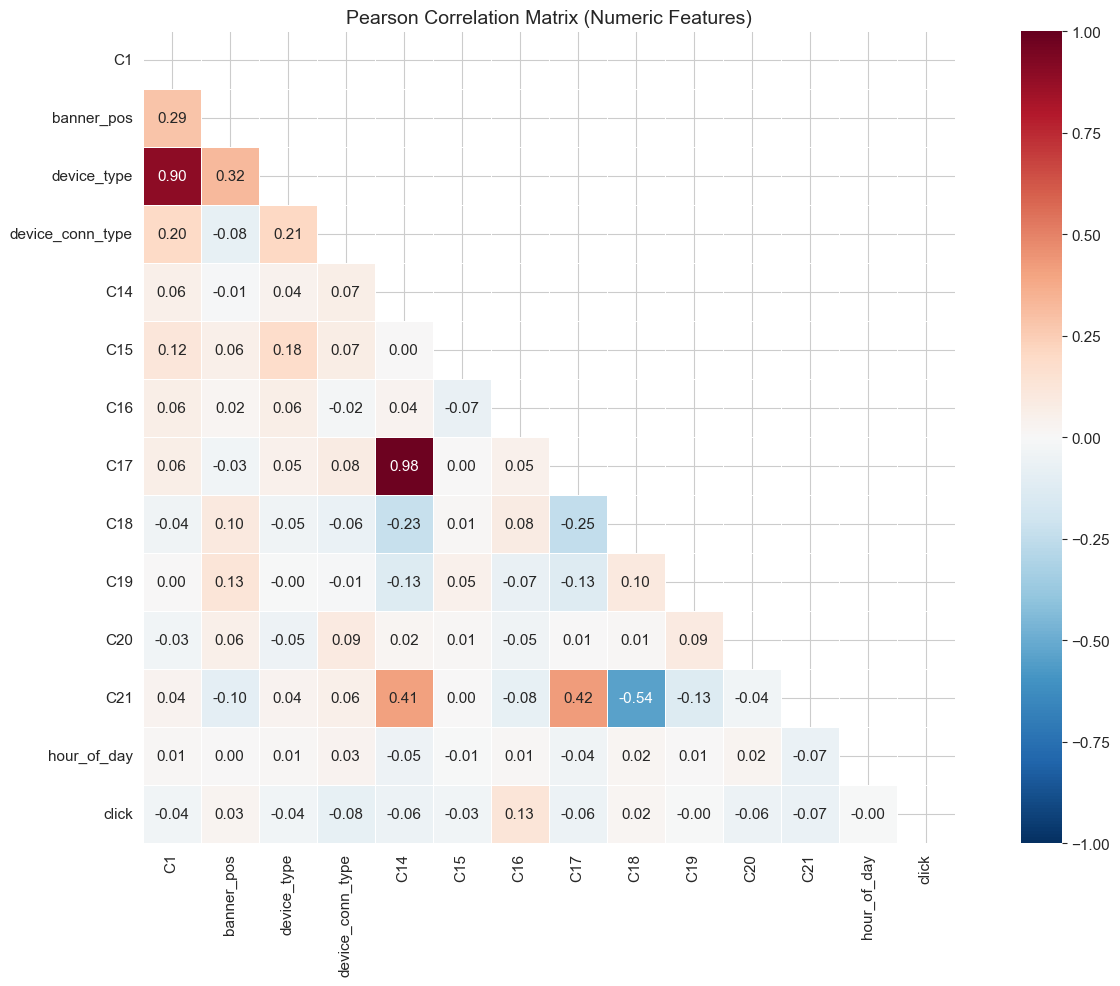

Highly correlated pairs (|r| > 0.7):
  C1  <->  device_type:  r = 0.895
  C14  <->  C17:  r = 0.977


In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['id', 'hour', 'date']
numeric_feat = [c for c in numeric_cols if c not in exclude and c != 'click']

corr_matrix = df[numeric_feat + ['click']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Pearson Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], round(r, 3)))

if high_corr_pairs:
    print("Highly correlated pairs (|r| > 0.7):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1}  <->  {f2}:  r = {r}")
else:
    print("No feature pairs with |r| > 0.7 found.")

**Note on Pearson Correlation**

Pearson correlation only measures **linear** relationships between **numeric** variables. Since most of our features are categorical (even if integer-coded), Pearson is kept here as a **reference only**. The real feature-association analysis is done via Cramer's V below.

High linear correlations between numeric features (e.g., C15 <-> C16) are noted — but the decision to drop or keep features will be based on Cramer's V results.

## 2.6  Cramer's V Association Matrix

In [19]:
def cramers_v(x, y):
    """Compute Cramér's V statistic for two categorical Series."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    min_dim = min(confusion.shape[0], confusion.shape[1]) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min_dim))

def bin_high_card(series, max_cats=50):
    """Keep top max_cats categories, group the rest as 'OTHER'."""
    top_cats = series.value_counts().nlargest(max_cats).index
    return series.where(series.isin(top_cats), other='OTHER')

# Features to analyze
cramer_features = ['C1', 'banner_pos', 'site_category', 'app_category',
                   'device_type', 'device_conn_type',
                   'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
                   'hour_of_day', 'is_weekend', 'click']

# Recreate hour_of_day / is_weekend if cleaned up
if 'hour_of_day' not in df.columns:
    df['hour_of_day'] = df['hour'] % 100
if 'is_weekend' not in df.columns:
    date_tmp = df['hour'] // 100
    df['is_weekend'] = (pd.to_datetime(date_tmp.astype(str), format='%y%m%d')
                        .dt.dayofweek >= 5).astype(int)

# Bin high-cardinality numeric features for chi2
df_binned = df[cramer_features].copy()
for col in ['C14', 'C17', 'C19', 'C20', 'C21']:
    df_binned[col] = pd.qcut(df_binned[col], q=20, duplicates='drop').astype(str)

# Compute matrix
n_feat = len(cramer_features)
cramer_matrix = pd.DataFrame(np.zeros((n_feat, n_feat)),
                              index=cramer_features, columns=cramer_features)

print("Computing Cramer's V matrix...")
for i in range(n_feat):
    cramer_matrix.iloc[i, i] = 1.0
    for j in range(i+1, n_feat):
        v = cramers_v(df_binned[cramer_features[i]], df_binned[cramer_features[j]])
        cramer_matrix.iloc[i, j] = v
        cramer_matrix.iloc[j, i] = v

cramer_matrix = cramer_matrix.astype(float)

Computing Cramer's V matrix...


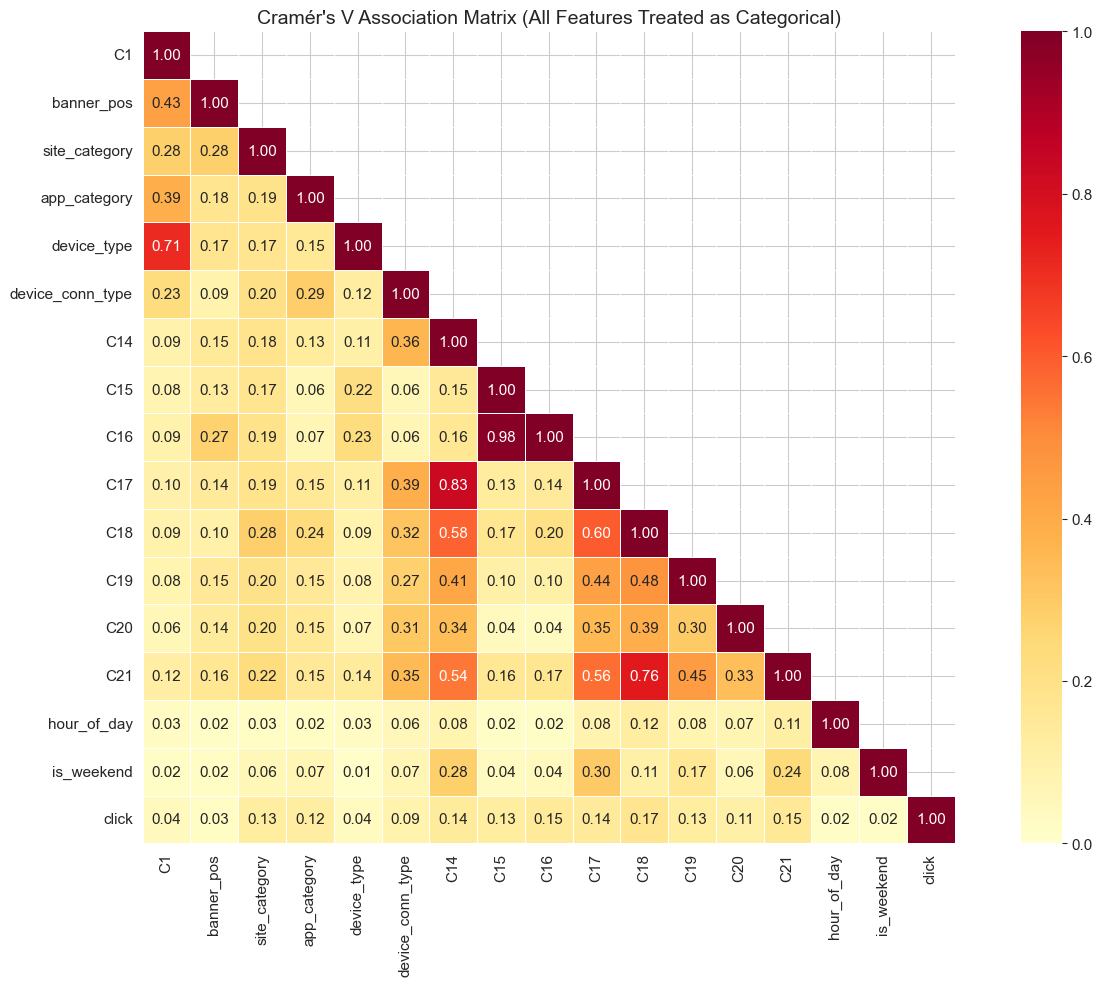


Cramér's V with target (click):
C18                 0.173151
C21                 0.152792
C16                 0.145795
C17                 0.143130
C14                 0.139847
C19                 0.127433
site_category       0.126256
C15                 0.125633
app_category        0.123573
C20                 0.107802
device_conn_type    0.087649
C1                  0.040386
device_type         0.038676
banner_pos          0.026731
hour_of_day         0.019255
is_weekend          0.016564


Highly associated feature pairs (Cramér's V > 0.5, excluding target):
  C1  <->  device_type:  V = 0.707
  C14  <->  C17:  V = 0.828
  C14  <->  C18:  V = 0.584
  C14  <->  C21:  V = 0.540
  C15  <->  C16:  V = 0.983
  C17  <->  C18:  V = 0.599
  C17  <->  C21:  V = 0.560
  C18  <->  C21:  V = 0.755


In [20]:
# V Heatmap + Feature Ranking
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(cramer_matrix, dtype=bool), k=1)
sns.heatmap(cramer_matrix, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1,
            mask=mask, linewidths=0.5, square=True)
plt.title("Cramér's V Association Matrix (All Features Treated as Categorical)")
plt.tight_layout()
plt.show()

# Association with target
target_assoc = cramer_matrix['click'].drop('click').sort_values(ascending=False)
print("\nCramér's V with target (click):")
print(target_assoc.to_string())

# High inter-feature association
print("\n\nHighly associated feature pairs (Cramér's V > 0.5, excluding target):")
feat_only = [f for f in cramer_features if f != 'click']
for i in range(len(feat_only)):
    for j in range(i+1, len(feat_only)):
        v = cramer_matrix.loc[feat_only[i], feat_only[j]]
        if v > 0.5:
            print(f"  {feat_only[i]}  <->  {feat_only[j]}:  V = {v:.3f}")

**Conclusion 2.6 — Cramer's V Feature Association & Selection**

Cramer's V is the correct association measure here because virtually all features in this dataset are **categorical in nature** (even integer-coded ones like C1, C15, C16 represent category codes, not continuous quantities).

**Feature selection decisions based on Cramer's V:**

1. **Features with highest V(click)** -> These are the most predictive and will be prioritized. The anonymized features `C18` (0.173), `C21` (0.153), `C16` (0.146), `C17` (0.143), and `C14` (0.140) rank highest, followed by `C19`, `site_category`, `C15`, and `app_category`.

2. **Highly inter-associated pairs (V > 0.5)** → When two features are strongly associated with each other:
   - If both have similar V(click), keep the one that is easier to interpret or more stable across time.
   - If one has clearly higher V(click), keep that one and consider dropping the redundant one.
   - Specific pairs from the output: `C1 <-> device_type` (V=0.707) and `C14 <-> C17` (V=0.828) — these are highly redundant and we may consider dropping one from each pair.

3. **Features with very low V(click) < 0.03** → Candidates for removal (e.g., `banner_pos` at 0.027, `hour_of_day` at 0.019, `is_weekend` at 0.017). However, we do NOT drop them yet — tree models are robust to irrelevant features, so we will let SHAP analysis in Part 6 make the final call.

4. **Cramer's V overrides Pearson** for feature decisions in this project, because Pearson misrepresents relationships between encoded categoricals.

# Part 3 — Feature Engineering

**Goals:**
1. **Fix LabelEncoder bug** — fit on train only, handle unseen categories in test with a special value.
2. **Target encoding** — 5-fold CV on train to avoid leakage; use full train stats for test. Applied to high-cardinality columns (`site_id`, `site_domain`, `app_id`, `app_domain`, `device_id`, `device_ip`, `device_model`).
3. **Cross features** — `site_category × hour_of_day`, `app_category × hour_of_day`, `site_category × device_type` (motivated by EDA: site vs. app behavior differs by time).
4. **Count features** — frequency counts for `device_ip`, `device_id`, `site_id`, `app_id` (proxy for popularity/activity level).
5. **All feature engineering wrapped in reusable functions** — train and test go through the same pipeline.

Define Column Groups

In [21]:
# High-cardinality columns -> target encoding
HIGH_CARD_COLS = [
    'site_id', 'site_domain', 'app_id', 'app_domain',
    'device_id', 'device_ip', 'device_model'
]

# Low-cardinality columns -> safe for label encoding
LOW_CARD_COLS = [
    'site_category', 'app_category'
]

# Columns for count features (frequency-based)
COUNT_COLS = ['device_ip', 'device_id', 'site_id', 'app_id']

# Cross-feature pairs: (col_a, col_b) -> "col_a_x_col_b"
CROSS_PAIRS = [
    ('site_category', 'hour_of_day'),
    ('app_category',  'hour_of_day'),
    ('site_category', 'device_type'),
]

# Columns to drop before modeling (raw IDs, intermediate cols)
DROP_COLS = ['id', 'hour', 'date']

# Global mean for smoothing
GLOBAL_CLICK_RATE = None  # set after data is available

print("Column groups defined.")

Column groups defined.


Time Feature Extraction (uses parse_hour_features from Part 0)

In [22]:
# Step 1: Extract time features
print("Extracting time features from 'hour' column...")

# Idempotent guard: skip if 'date' already exists as datetime
if 'date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['date']):
    print("  Train 'date' already exists as datetime — skipping re-parse.")
else:
    df = parse_hour_features(df)

if 'date' in test_df.columns and pd.api.types.is_datetime64_any_dtype(test_df['date']):
    print("  Test 'date' already exists as datetime — skipping re-parse.")
else:
    test_df = parse_hour_features(test_df)

print(f"  New columns added: hour_of_day, day_of_week, is_weekend")
print(f"  Train 'date' range: {df['date'].min()} → {df['date'].max()}")
print(f"  Test  'date' range: {test_df['date'].min()} → {test_df['date'].max()}")

Extracting time features from 'hour' column...
  New columns added: hour_of_day, day_of_week, is_weekend
  Train 'date' range: 2014-10-21 00:00:00 → 2014-10-30 23:00:00
  Test  'date' range: 2014-10-31 00:00:00 → 2014-10-31 23:00:00


In [23]:
def target_encode_train(df, cols, target='click', n_folds=5, smoothing=20, random_state=42):
    """
    Target encode high-cardinality columns on the TRAINING set using 5-fold CV
    to prevent target leakage.
    
    For each fold: compute target mean from out-of-fold data, apply to in-fold rows.
    Uses additive smoothing: (count * mean + smoothing * global_mean) / (count + smoothing)
    
    Returns:
        df : DataFrame with new '{col}_te' columns
        te_maps : dict of {col: {category: smoothed_target_mean}} fitted on full train
                  (used later for test encoding)
    """
    global_mean = df[target].mean()
    te_maps = {}
    
    # Initialize new columns
    for col in cols:
        df[col + '_te'] = np.nan
    
    # 5-fold CV encoding to avoid leakage
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df, df[target])):
        for col in cols:
            # Compute stats from OOF (out-of-fold) portion only
            oof_data = df.iloc[train_idx]
            stats = oof_data.groupby(col)[target].agg(['mean', 'count'])
            
            # Smoothed target mean
            smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / \
                       (stats['count'] + smoothing)
            
            # Apply to in-fold rows
            df.loc[df.index[val_idx], col + '_te'] = \
                df.iloc[val_idx][col].map(smoothed).values
    
    # Fill any remaining NaN with global mean (shouldn't happen, but safety net)
    for col in cols:
        df[col + '_te'].fillna(global_mean, inplace=True)
    
    # Build full-train te_maps for test-time encoding
    for col in cols:
        stats = df.groupby(col)[target].agg(['mean', 'count'])
        smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / \
                   (stats['count'] + smoothing)
        te_maps[col] = smoothed.to_dict()
    
    return df, te_maps


def target_encode_test(df, cols, te_maps, global_mean):
    """
    Apply pre-computed target encoding maps to the TEST set.
    Unseen categories get the global mean.
    """
    for col in cols:
        df[col + '_te'] = df[col].map(te_maps[col]).fillna(global_mean)
    return df


print("Target encoding functions defined.")

Target encoding functions defined.


In [24]:
# Step 2: Target encoding 
print("Applying 5-fold target encoding on training set...")
t0 = time.time()

GLOBAL_CLICK_RATE = df['click'].mean()
df, te_maps = target_encode_train(df, HIGH_CARD_COLS, target='click', n_folds=5, smoothing=20)

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Global click rate (smoothing prior): {GLOBAL_CLICK_RATE:.6f}")

# Sanity check: show a few target-encoded columns
print("\nTarget-encoded column stats:")
for col in HIGH_CARD_COLS:
    te_col = col + '_te'
    print(f"  {te_col:25s}  mean={df[te_col].mean():.4f}  "
          f"std={df[te_col].std():.4f}  "
          f"NaN={df[te_col].isna().sum()}")

Applying 5-fold target encoding on training set...
  Done in 105.6s
  Global click rate (smoothing prior): 0.169806

Target-encoded column stats:
  site_id_te                 mean=0.1699  std=0.1026  NaN=691
  site_domain_te             mean=0.1698  std=0.0961  NaN=1365
  app_id_te                  mean=0.1701  std=0.0695  NaN=1678
  app_domain_te              mean=0.1699  std=0.0507  NaN=95
  device_id_te               mean=0.1736  std=0.0217  NaN=438125
  device_ip_te               mean=0.1698  std=0.0554  NaN=1292301
  device_model_te            mean=0.1697  std=0.0646  NaN=1091


In [25]:
print("Applying target encoding to test set...")
test_df = target_encode_test(test_df, HIGH_CARD_COLS, te_maps, GLOBAL_CLICK_RATE)

# Check for unseen categories mapped to global mean
for col in HIGH_CARD_COLS:
    te_col = col + '_te'
    n_unseen = (test_df[te_col] == GLOBAL_CLICK_RATE).sum()
    pct = n_unseen / len(test_df) * 100
    print(f"  {col:20s}  unseen -> global_mean: {n_unseen:>8,} ({pct:.2f}%)")

Applying target encoding to test set...
  site_id               unseen -> global_mean:  819,635 (17.91%)
  site_domain           unseen -> global_mean:    2,724 (0.06%)
  app_id                unseen -> global_mean:   20,750 (0.45%)
  app_domain            unseen -> global_mean:      727 (0.02%)
  device_id             unseen -> global_mean:  497,899 (10.88%)
  device_ip             unseen -> global_mean: 2,170,767 (47.42%)
  device_model          unseen -> global_mean:      986 (0.02%)


In [26]:
def safe_label_encode(train_df, test_df, cols, unseen_value=-1):
    """
    LabelEncoder fit on TRAIN only.
    Test categories not seen in train -> encoded as `unseen_value`.
    
    Returns:
        train_df, test_df : with columns replaced by integer codes
        le_dict : dict of {col: fitted LabelEncoder}
    """
    le_dict = {}
    
    for col in cols:
        le = LabelEncoder()
        # Fit on train
        le.fit(train_df[col].astype(str))
        le_dict[col] = le
        
        # Transform train
        train_df[col + '_le'] = le.transform(train_df[col].astype(str))
        
        # Transform test — handle unseen categories
        known = set(le.classes_)
        test_df[col + '_le'] = test_df[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in known else unseen_value
        )
    
    return train_df, test_df, le_dict


print("Safe label encoding function defined.")

Safe label encoding function defined.


In [27]:
# Step 3: Label encoding for low-cardinality categoricals 
print("Label encoding low-cardinality columns...")
df, test_df, le_dict = safe_label_encode(df, test_df, LOW_CARD_COLS)

for col in LOW_CARD_COLS:
    le_col = col + '_le'
    train_unique = df[le_col].nunique()
    test_unique = test_df[le_col].nunique()
    unseen_count = (test_df[le_col] == -1).sum()
    print(f"  {col:20s}  train_unique={train_unique}  test_unique={test_unique}  "
          f"unseen_in_test={unseen_count}")

Label encoding low-cardinality columns...
  site_category         train_unique=23  test_unique=21  unseen_in_test=2
  app_category          train_unique=29  test_unique=26  unseen_in_test=13


In [28]:
def add_cross_features(df, cross_pairs):
    """
    Create interaction features by concatenating two columns as strings,
    then integer-hashing to keep cardinality manageable.
    """
    for col_a, col_b in cross_pairs:
        cross_name = f"{col_a}_x_{col_b}"
        # String concatenation -> hash to integer
        df[cross_name] = (
            df[col_a].astype(str) + "_" + df[col_b].astype(str)
        ).apply(hash).astype(np.int64) % (10**6)  # mod to limit range
    return df


print("Cross feature function defined.")

Cross feature function defined.


In [29]:
# Step 4: Cross features 
print("Adding cross features...")
df = add_cross_features(df, CROSS_PAIRS)
test_df = add_cross_features(test_df, CROSS_PAIRS)

for col_a, col_b in CROSS_PAIRS:
    cross_name = f"{col_a}_x_{col_b}"
    print(f"  {cross_name:40s}  train_unique={df[cross_name].nunique():>6,}  "
          f"test_unique={test_df[cross_name].nunique():>6,}")

Adding cross features...
  site_category_x_hour_of_day               train_unique=   460  test_unique=   390
  app_category_x_hour_of_day                train_unique=   538  test_unique=   494
  site_category_x_device_type               train_unique=    30  test_unique=    27


In [30]:
def add_count_features(train_df, test_df, cols, suffix='_count'):
    """
    Frequency count features — fit on train, apply mapping to test.
    Unseen categories in test get count = 1 (minimum plausible count).
    
    Returns updated train_df, test_df, and count_maps dict.
    """
    count_maps = {}
    
    for col in cols:
        # Compute counts on train
        counts = train_df[col].value_counts().to_dict()
        count_maps[col] = counts
        
        count_col = col + suffix
        train_df[count_col] = train_df[col].map(counts).astype(int)
        test_df[count_col]  = test_df[col].map(counts).fillna(1).astype(int)
    
    return train_df, test_df, count_maps


print("Count feature function defined.")

Count feature function defined.


In [31]:
# Step 5: Count features 
print("Adding count features...")
df, test_df, count_maps = add_count_features(df, test_df, COUNT_COLS)

for col in COUNT_COLS:
    count_col = col + '_count'
    print(f"  {count_col:25s}  train: mean={df[count_col].mean():.1f}, "
          f"max={df[count_col].max():,}  |  "
          f"test: mean={test_df[count_col].mean():.1f}, "
          f"max={test_df[count_col].max():,}")

Adding count features...
  device_ip_count            train: mean=515.0, max=20,715  |  test: mean=381.5, max=20,715
  device_id_count            train: mean=2750480.2, max=3,334,650  |  test: mean=2871502.3, max=3,334,650
  site_id_count              train: mean=660280.5, max=1,459,754  |  test: mean=632601.5, max=1,459,754
  app_id_count               train: mean=1667507.7, max=2,583,142  |  test: mean=1630870.7, max=2,583,142


In [32]:
# Step 6: Drop raw columns that are no longer needed
# NOTE: 'hour' is kept — Part 4 may need it to reconstruct 'date' on re-run.
#       'hour' will be excluded from modeling features in Part 4 (Cell 67).
# NOTE: 'date' is NOT dropped here — Part 4 needs it for time-based splitting.

# Also drop the raw high-cardinality string columns (replaced by _te versions)
# And drop raw low-cardinality string columns (replaced by _le versions)
raw_to_drop = ['id'] + HIGH_CARD_COLS + LOW_CARD_COLS

# Save test IDs for final submission BEFORE dropping
test_ids = test_df['id'].values if 'id' in test_df.columns else None

# Only drop columns that actually exist
train_drop = [c for c in raw_to_drop if c in df.columns]
test_drop  = [c for c in raw_to_drop if c in test_df.columns]

print(f"Dropping {len(train_drop)} raw columns from train: {train_drop}")
df.drop(columns=train_drop, inplace=True)

print(f"Dropping {len(test_drop)} raw columns from test:  {test_drop}")
test_df.drop(columns=test_drop, inplace=True)

print(f"\nFinal train shape: {df.shape}")
print(f"Final test shape:  {test_df.shape}")

Dropping 10 raw columns from train: ['id', 'site_id', 'site_domain', 'app_id', 'app_domain', 'device_id', 'device_ip', 'device_model', 'site_category', 'app_category']
Dropping 10 raw columns from test:  ['id', 'site_id', 'site_domain', 'app_id', 'app_domain', 'device_id', 'device_ip', 'device_model', 'site_category', 'app_category']

Final train shape: (4042896, 35)
Final test shape:  (4577464, 33)


Verify Final Feature Set

In [33]:
print("Final Training Columns")
print(df.columns.tolist())
print(f"\nTotal features: {df.shape[1] - 1} (excluding 'click')")
print(f"\nData types")
print(df.dtypes.value_counts())

# Check for any remaining object columns (shouldn't be any)
obj_cols = df.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f"\n Object columns still present: {obj_cols}")
else:
    print("\n All columns are numeric — ready for modeling.")

Final Training Columns
['click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'traffic_source', 'hour_of_day', 'is_weekend', 'date', 'day_of_week', 'site_id_te', 'site_domain_te', 'app_id_te', 'app_domain_te', 'device_id_te', 'device_ip_te', 'device_model_te', 'site_category_le', 'app_category_le', 'site_category_x_hour_of_day', 'app_category_x_hour_of_day', 'site_category_x_device_type', 'device_ip_count', 'device_id_count', 'site_id_count', 'app_id_count']

Total features: 34 (excluding 'click')

Data types
int64             24
float64            7
int32              2
str                1
datetime64[us]     1
Name: count, dtype: int64

 Object columns still present: ['traffic_source']


Sanity Check: Feature Distributions

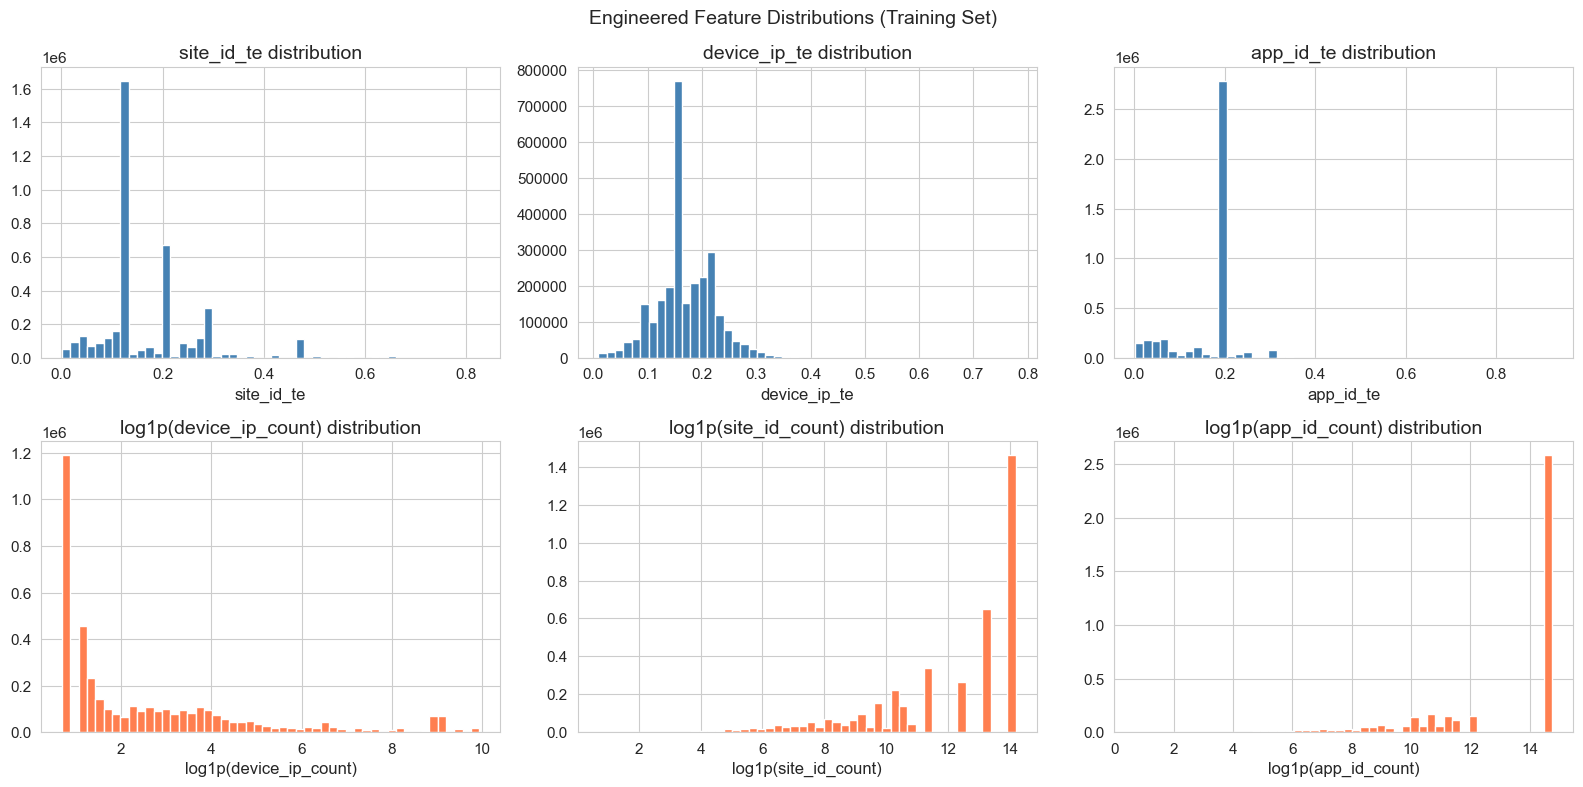

In [34]:
# Spot-check a few engineered features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Target-encoded features
for ax, col in zip(axes[0], ['site_id_te', 'device_ip_te', 'app_id_te']):
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)

# Count features
for ax, col in zip(axes[1], ['device_ip_count', 'site_id_count', 'app_id_count']):
    # Log scale for count features (heavy tail)
    np.log1p(df[col]).hist(bins=50, ax=ax, color='coral', edgecolor='white')
    ax.set_title(f'log1p({col}) distribution')
    ax.set_xlabel(f'log1p({col})')

plt.suptitle('Engineered Feature Distributions (Training Set)', fontsize=14)
plt.tight_layout()
plt.show()

### Part 3 Takeaways

**New features added:**
- **Target encoding** (7 high-cardinality columns): 5-fold CV on train prevents leakage. Additive smoothing (m=20) regularizes rare categories toward the global click rate (~17%).
- **Cross features** (3 pairs): `site_category × hour`, `app_category × hour`, `site_category × device_type` — captures the EDA finding that site vs. app CTR patterns differ by time of day and device.
- **Count features** (4 columns): `device_ip_count`, `device_id_count`, `site_id_count`, `app_id_count` — proxy for user activity level and site/app popularity. Fitted on train; unseen test values default to count=1.

**Pipeline design:**
- All feature engineering uses **functions** — `target_encode_train/test`, `safe_label_encode`, `add_cross_features`, `add_count_features`.
- Train and test go through the **same functions** with train-fitted parameters, ensuring no data leakage.

**Ready for Part 4:** All columns are now numeric. Next step is time-based train/val split and scaling.

# Part 4 — Data Split & Preprocessing

**Why time-based split instead of random split?**

CTR data is inherently temporal — user behavior, ad campaigns, and traffic patterns shift over time. A random split leaks future information into the training set, producing overly optimistic offline metrics that don't reflect real deployment. By splitting chronologically, we simulate the real scenario.

**Pipeline:**
1. Sort by `date` (parsed in Part 3) -> split into train, validation, and test by day cutoffs (~70/15/15% of *calendar days*; actual row counts differ because daily traffic volume is uneven).
2. `StandardScaler` fitted on **train only** -> applied to val and test (no data leakage).
3. `TimeSeriesSplit` configured for cross-validation in Part 5.
4. Output: clean `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [35]:
# Sort entire DataFrame by time (critical for temporal split)
df = df.sort_values('date').reset_index(drop=True)

# Identify unique calendar dates for split cutoffs
unique_dates = np.sort(df['date'].dt.date.unique())
n_dates = len(unique_dates)

print(f"Date range: {unique_dates[0]} -> {unique_dates[-1]}")
print(f"Unique calendar days: {n_dates}")
print(f"Total rows (now sorted by time): {len(df):,}")

Date range: 2014-10-21 -> 2014-10-30
Unique calendar days: 10
Total rows (now sorted by time): 4,042,896


In [36]:
# Split: ~70% train, ~15% val, ~15% test by calendar day 
# Splitting by DAY (not by row) ensures no single day is split across sets

train_cutoff_idx = int(n_dates * 0.70)
val_cutoff_idx   = int(n_dates * 0.85)

train_end_date = unique_dates[train_cutoff_idx]
val_end_date   = unique_dates[val_cutoff_idx]

print(f"Train period: {unique_dates[0]} -> {train_end_date}  (first ~70% of days)")
print(f"Val   period: {train_end_date} -> {val_end_date}  (next ~15% of days)")
print(f"Test  period: {val_end_date} -> {unique_dates[-1]}  (last ~15% of days)")

# Apply the splits
train_mask = df['date'].dt.date <= train_end_date
val_mask   = (df['date'].dt.date > train_end_date) & (df['date'].dt.date <= val_end_date)
test_mask  = df['date'].dt.date > val_end_date

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

print(f"\nTrain: {len(df_train):>10,} rows  ({len(df_train)/len(df):.1%})")
print(f"Val:   {len(df_val):>10,} rows  ({len(df_val)/len(df):.1%})")
print(f"Test:  {len(df_test):>10,} rows  ({len(df_test)/len(df):.1%})")

# Verify strict temporal ordering — no overlap
print(f"\nTrain max date: {df_train['date'].max()}")
print(f"Val   min date: {df_val['date'].min()}")
print(f"Val   max date: {df_val['date'].max()}")
print(f"Test  min date: {df_test['date'].min()}")

Train period: 2014-10-21 -> 2014-10-28  (first ~70% of days)
Val   period: 2014-10-28 -> 2014-10-29  (next ~15% of days)
Test  period: 2014-10-29 -> 2014-10-30  (last ~15% of days)

Train:  3,237,843 rows  (80.1%)
Val:      383,175 rows  (9.5%)
Test:     421,878 rows  (10.4%)

Train max date: 2014-10-28 23:00:00
Val   min date: 2014-10-29 00:00:00
Val   max date: 2014-10-29 23:00:00
Test  min date: 2014-10-30 00:00:00


Click rate per split:
  Train:   17.1484%
  Val:     15.6171%
  Test:    16.9307%
  Overall: 16.9806%


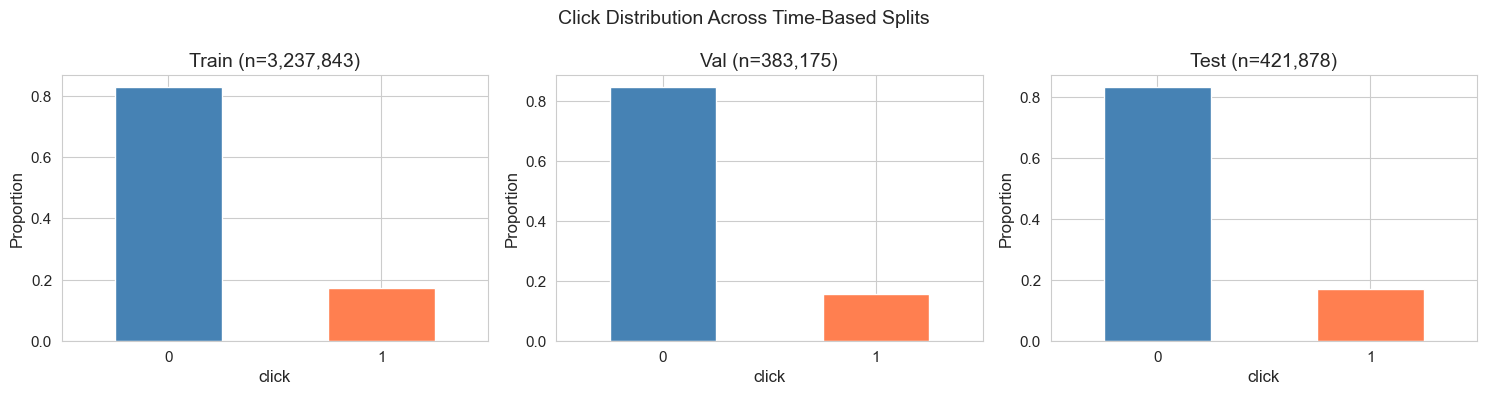

In [37]:
# Check for distribution shift across time-based splits
# (Some drift is expected and realistic — that's the whole point of temporal split)

print("Click rate per split:")
print(f"  Train:   {df_train['click'].mean():.4%}")
print(f"  Val:     {df_val['click'].mean():.4%}")
print(f"  Test:    {df_test['click'].mean():.4%}")
print(f"  Overall: {df['click'].mean():.4%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, split) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    split['click'].value_counts(normalize=True).plot.bar(ax=ax, color=['steelblue', 'coral'])
    ax.set_title(f'{name} (n={len(split):,})')
    ax.set_ylabel('Proportion')
    ax.set_xlabel('click')
    ax.set_xticklabels(['0', '1'], rotation=0)

plt.suptitle('Click Distribution Across Time-Based Splits', fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
# Drop 'date', 'hour', and 'click' to get feature matrices
# 'date' served its purpose for splitting — now remove it
# 'hour' was kept for robustness — now remove it before modeling
drop_for_modeling = ['click', 'date', 'hour']
drop_existing = [c for c in drop_for_modeling if c in df_train.columns]

y_train = df_train['click'].values
y_val   = df_val['click'].values
y_test  = df_test['click'].values

X_train = df_train.drop(columns=drop_existing)
X_val   = df_val.drop(columns=drop_existing)
X_test  = df_test.drop(columns=drop_existing)

# Store feature names for later use (SHAP, importance plots, etc.)
feature_names = X_train.columns.tolist()

print(f"Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nFeatures ({len(feature_names)}):")
print(feature_names)

Feature matrix shapes:
  X_train: (3237843, 32)
  X_val:   (383175, 32)
  X_test:  (421878, 32)

Features (32):
['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'traffic_source', 'hour_of_day', 'is_weekend', 'day_of_week', 'site_id_te', 'site_domain_te', 'app_id_te', 'app_domain_te', 'device_id_te', 'device_ip_te', 'device_model_te', 'site_category_le', 'app_category_le', 'site_category_x_hour_of_day', 'app_category_x_hour_of_day', 'site_category_x_device_type', 'device_ip_count', 'device_id_count', 'site_id_count', 'app_id_count']


In [39]:
# Safety net: target encoding on unseen categories or edge cases may leave NaN/Inf
for name, X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    nan_count = X.isnull().sum().sum()
    inf_count = np.isinf(X.select_dtypes(include=np.number)).sum().sum()
    if nan_count > 0 or inf_count > 0:
        print(f"  {name}: {nan_count} NaN, {inf_count} Inf -> filling with 0")
        X.fillna(0, inplace=True)
        X.replace([np.inf, -np.inf], 0, inplace=True)
    else:
        print(f"  {name}: clean (no NaN, no Inf)")

  X_train: 1379968 NaN, 0 Inf -> filling with 0
  X_val: 173583 NaN, 0 Inf -> filling with 0
  X_test: 181795 NaN, 0 Inf -> filling with 0


In [40]:
# GBDT models (LightGBM, XGBoost) don't need scaling — they split on thresholds.
# Logistic Regression and DeepFM DO need scaling.
# -> Maintain both: X_* (unscaled) for GBDT, X_*_scaled for LR/DeepFM.

# Drop 'traffic_source' if it survived — it was an EDA-only column (string),
# not meant for modeling. Site/app behavior is already captured by
# site_category_le, app_category_le, and the cross features.
for _df in [X_train, X_val, X_test]:
    if 'traffic_source' in _df.columns:
        _df.drop(columns=['traffic_source'], inplace=True)

# Update feature_names after potential drop
feature_names = X_train.columns.tolist()

scaler = StandardScaler()
scaler.fit(X_train)  # Fit ONLY on training data — no leakage

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train), 
    columns=feature_names, 
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), 
    columns=feature_names, 
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=feature_names, 
    index=X_test.index
)

print("StandardScaler fitted on train, applied to val and test.")
print(f"\nTrain scaled sanity check (should be ~0 mean, ~1 std):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4).to_string())

StandardScaler fitted on train, applied to val and test.

Train scaled sanity check (should be ~0 mean, ~1 std):
       C1  banner_pos  device_type  device_conn_type  C14  C15  C16  C17  C18  C19  C20  C21  hour_of_day  is_weekend  day_of_week  site_id_te  site_domain_te  app_id_te  app_domain_te  device_id_te  device_ip_te  device_model_te  site_category_le  app_category_le  site_category_x_hour_of_day  app_category_x_hour_of_day  site_category_x_device_type  device_ip_count  device_id_count  site_id_count  app_id_count
mean -0.0        -0.0          0.0               0.0  0.0  0.0  0.0  0.0  0.0 -0.0  0.0 -0.0          0.0         0.0         -0.0        -0.0            -0.0        0.0           -0.0           0.0           0.0             -0.0               0.0             -0.0                          0.0                         0.0                          0.0             -0.0             -0.0           -0.0           0.0
std   1.0         1.0          1.0               1.0  1.0  

In [41]:
# TimeSeriesSplit for use in GridSearchCV in Part 5.
# Since X_train is already sorted by time, each fold trains on earlier rows
# and validates on the next chronological block.
# n_splits=5: fold 1 trains on first 1/6, validates on 2/6, etc.

tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit configured (n_splits=5):")
print("Used as cv=tscv in GridSearchCV in Part 5.\n")

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    train_dates = df_train.iloc[train_idx]['date'] if 'date' in df_train.columns else None
    val_dates   = df_train.iloc[val_idx]['date'] if 'date' in df_train.columns else None
    print(f"  Fold {i+1}: train ({len(train_idx):>7,} rows)  |  val ({len(val_idx):>7,} rows)")

TimeSeriesSplit configured (n_splits=5):
Used as cv=tscv in GridSearchCV in Part 5.

  Fold 1: train (539,643 rows)  |  val (539,640 rows)
  Fold 2: train (1,079,283 rows)  |  val (539,640 rows)
  Fold 3: train (1,618,923 rows)  |  val (539,640 rows)
  Fold 4: train (2,158,563 rows)  |  val (539,640 rows)
  Fold 5: train (2,698,203 rows)  |  val (539,640 rows)


In [42]:
# LightGBM's native categorical_feature support:
# Low-cardinality label-encoded columns should be declared as categorical.
# High-cardinality columns are already target-encoded (continuous) -> NOT categorical.

lgb_categorical_features = [
    c for c in feature_names 
    if c in ['C1', 'banner_pos', 'site_category_le', 'app_category_le',
             'device_type', 'device_conn_type', 'C15', 'C16', 'C18']
]

print(f"LightGBM categorical features ({len(lgb_categorical_features)}):")
print(lgb_categorical_features)

LightGBM categorical features (9):
['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'site_category_le', 'app_category_le']


In [43]:
print("=" * 60)
print("  Part 4 Complete — Data Ready for Modeling")
print("=" * 60)
print(f"\n  Datasets:")
print(f"    GBDT (unscaled):    X_train, X_val, X_test")
print(f"    LR/DeepFM (scaled): X_train_scaled, X_val_scaled, X_test_scaled")
print(f"\n  Targets: y_train, y_val, y_test")
print(f"\n  CV strategy: tscv (TimeSeriesSplit, 5 folds)")
print(f"  LGB categoricals: lgb_categorical_features")
print(f"\n  Feature count: {len(feature_names)}")
print(f"  Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

  Part 4 Complete — Data Ready for Modeling

  Datasets:
    GBDT (unscaled):    X_train, X_val, X_test
    LR/DeepFM (scaled): X_train_scaled, X_val_scaled, X_test_scaled

  Targets: y_train, y_val, y_test

  CV strategy: tscv (TimeSeriesSplit, 5 folds)
  LGB categoricals: lgb_categorical_features

  Feature count: 31
  Train: 3,237,843  |  Val: 383,175  |  Test: 421,878


### Part 4 Takeaways

**Time-based split (not random):**
- Train = earliest ~70% of calendar days, Val = next ~15%, Test = final ~15%. Actual row splits are ~80%/10%/10% because daily traffic volume is uneven.
- Simulates real deployment: model never sees future data during training.
- Click rates may differ across splits (temporal drift) — this is expected and realistic.

**Scaler discipline:**
- `StandardScaler` fitted on training set ONLY -> val and test transformed with the same parameters.
- Two versions maintained: unscaled (`X_train/val/test`) for GBDT, scaled (`X_*_scaled`) for LR and DeepFM.

**Cross-validation:**
- `TimeSeriesSplit(n_splits=5)` respects temporal ordering — each fold trains on earlier data, validates on later data.
- Used as `cv=tscv` in `RandomizedSearchCV` in Part 5, replacing `StratifiedKFold` which would leak future info.

**Ready for Part 5:** `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `tscv`, `scaler`, `feature_names`, `lgb_categorical_features` all defined.

# Part 5 — Modeling

**Strategy:** Build models in layers, each adding complexity. Every model's predicted probabilities
are evaluated on the **held-out validation set** using `evaluate_model()` (LogLoss, AUC-ROC, PR-AUC)
and appended to the global `results` list.

| Layer | Model | Purpose |
|-------|-------|---------| 
| 1 | Logistic Regression | Establish a linear lower bound |
| 2 | LightGBM / XGBoost | GBDT with tuned hyperparameters |
| 3 | SMOTE experiment | Resample + retrain Layer 2 models, compare with/without |
| 4 | DeepFM (PyTorch) | Capture second-order (FM) + higher-order (DNN) feature interactions |
| 5 | Ensemble | Stack or blend predicted probabilities from Layers 1-4 |

**All hyperparameter searches use `RandomizedSearchCV` with `scoring='neg_log_loss'`** (aligned with the Kaggle metric)
and `cv=tscv` (TimeSeriesSplit — no future leakage).

## Layer 1 — Logistic Regression (Baseline)

A linear model sets the **lower bound** on performance.

Uses scaled features (`X_train_scaled`) since LR is distance-sensitive.

  Model: Logistic Regression
  LogLoss : 0.385605
  AUC-ROC : 0.735573
  PR-AUC  : 0.337165
  Notes   : Layer 1 baseline, scaled features


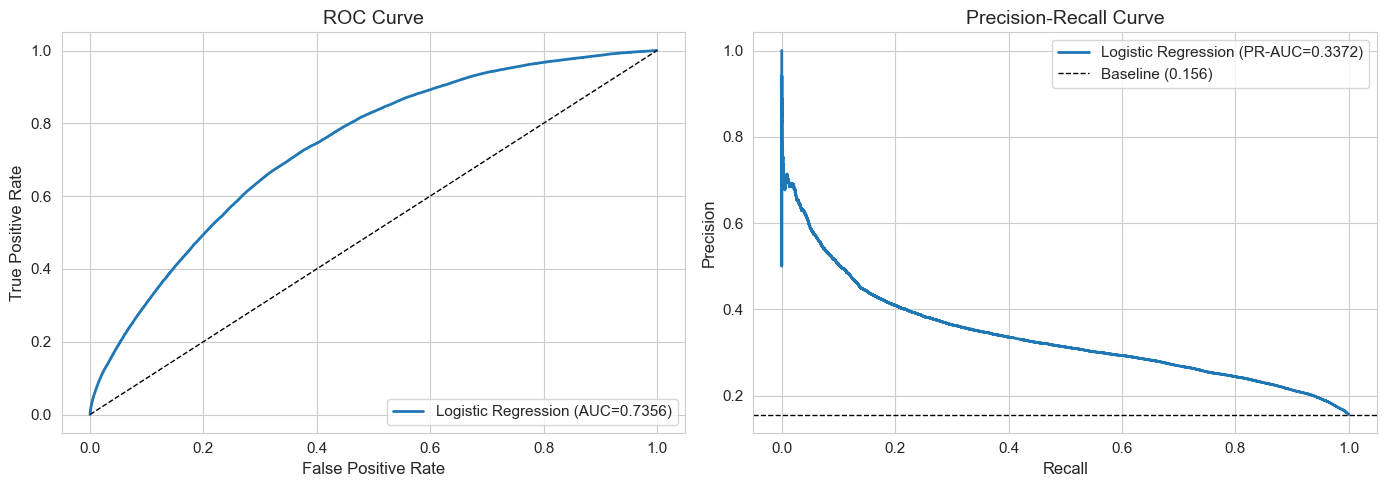

In [44]:
# Layer 1: Logistic Regression baseline
lr = LogisticRegression(
    max_iter=50000,
    solver='lbfgs',
    random_state=12138,
    n_jobs=-1
)
lr.fit(X_train_scaled, y_train)

lr_prob_val  = lr.predict_proba(X_val_scaled)[:, 1]
lr_prob_test = lr.predict_proba(X_test_scaled)[:, 1]

rec = evaluate_model(y_val, lr_prob_val, "Logistic Regression", notes="Layer 1 baseline, scaled features")
results.append(rec)

plot_roc_pr_curves(y_val, lr_prob_val, "Logistic Regression")

## Layer 2 — Boosting

Two GBDT implementations:
- **LightGBM**: uses native `categorical_feature` support for the low-cardinality columns identified in Part 4.
- **XGBoost**: experiments with `scale_pos_weight` to handle class imbalance at the loss level.

Both are tuned via `RandomizedSearchCV` (n_iter=15) with `scoring='neg_log_loss'` and `cv=tscv`.

Hyperparameter grids cover: `num_leaves`, `min_child_samples`, `subsample`,
`colsample_bytree`, `learning_rate`, `n_estimators`, `max_depth`, and `reg_alpha`/`reg_lambda`.

In [45]:
# Layer 2a: LightGBM with native categorical support
lgb_param_grid = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [50, 100, 200],
    'subsample':         [0.7, 0.9],
    'colsample_bytree':  [0.7, 0.9],
    'reg_alpha':         [0, 0.1],
    'reg_lambda':        [0, 1.0],
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    random_state=12138,
    verbose=-1,
    n_jobs=-1, 
)

# NOTE: GridSearchCV with this many combos on 3M rows is expensive.
# In practice, use RandomizedSearchCV or reduce the grid.
# Here we use RandomizedSearchCV with 15 iterations for tractability.

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_grid,
    n_iter=15,
    scoring='neg_log_loss',
    cv=tscv,
    random_state=12138,
    verbose=1,
    n_jobs=1, 
)

lgb_search.fit(
    X_train, y_train,
    categorical_feature=lgb_categorical_features,
)

print(f"\nBest LGB params: {lgb_search.best_params_}")
print(f"Best CV neg_log_loss: {lgb_search.best_score_:.6f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best LGB params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 100, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV neg_log_loss: -0.394566


  Model: LightGBM
  LogLoss : 0.374233
  AUC-ROC : 0.758505
  PR-AUC  : 0.365005
  Notes   : Layer 2, tuned via RandomizedSearchCV


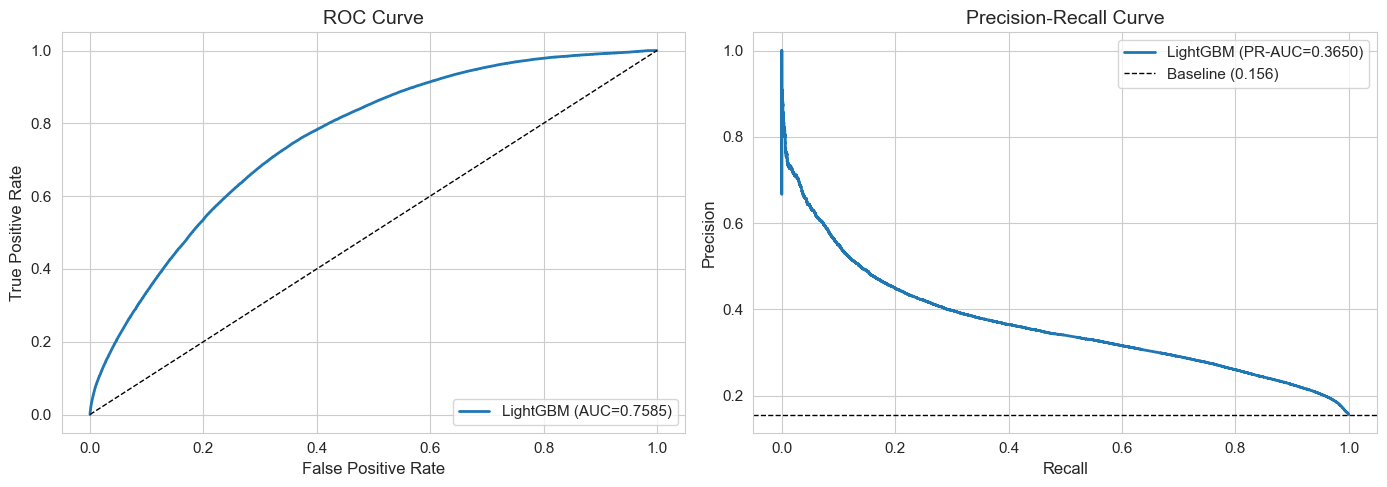

In [46]:
best_lgb = lgb_search.best_estimator_

lgb_prob_val  = best_lgb.predict_proba(X_val)[:, 1]
lgb_prob_test = best_lgb.predict_proba(X_test)[:, 1]

rec = evaluate_model(y_val, lgb_prob_val, "LightGBM", notes="Layer 2, tuned via RandomizedSearchCV")
results.append(rec)

plot_roc_pr_curves(y_val, lgb_prob_val, "LightGBM")

In [47]:
# Layer 2b: XGBoost with scale_pos_weight
# scale_pos_weight = n_negative / n_positive -> compensates for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {neg_count} / {pos_count} = {spw:.2f}")

xgb_param_grid = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.05, 0.1],
    'max_depth':         [5, 7, 9],
    'min_child_weight':  [5, 10, 50],
    'subsample':         [0.7, 0.9],
    'colsample_bytree':  [0.7, 0.9],
    'reg_alpha':         [0, 0.1],
    'reg_lambda':        [1.0, 5.0],
    'scale_pos_weight':  [1, spw],   # compare default vs imbalance-adjusted
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=12138,
    tree_method='hist',     # fast histogram-based method
    verbosity=0,
    n_jobs=-1,
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring='neg_log_loss',
    cv=tscv,
    random_state=12138,
    verbose=1,
    n_jobs=1,
)

xgb_search.fit(X_train, y_train)

print(f"\nBest XGB params: {xgb_search.best_params_}")
print(f"Best CV neg_log_loss: {xgb_search.best_score_:.6f}")

scale_pos_weight = 2682605 / 555238 = 4.83
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best XGB params: {'subsample': 0.7, 'scale_pos_weight': 1, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV neg_log_loss: -0.395032


  Model: XGBoost
  LogLoss : 0.373707
  AUC-ROC : 0.759602
  PR-AUC  : 0.365671
  Notes   : Layer 2, tuned, scale_pos_weight experimented


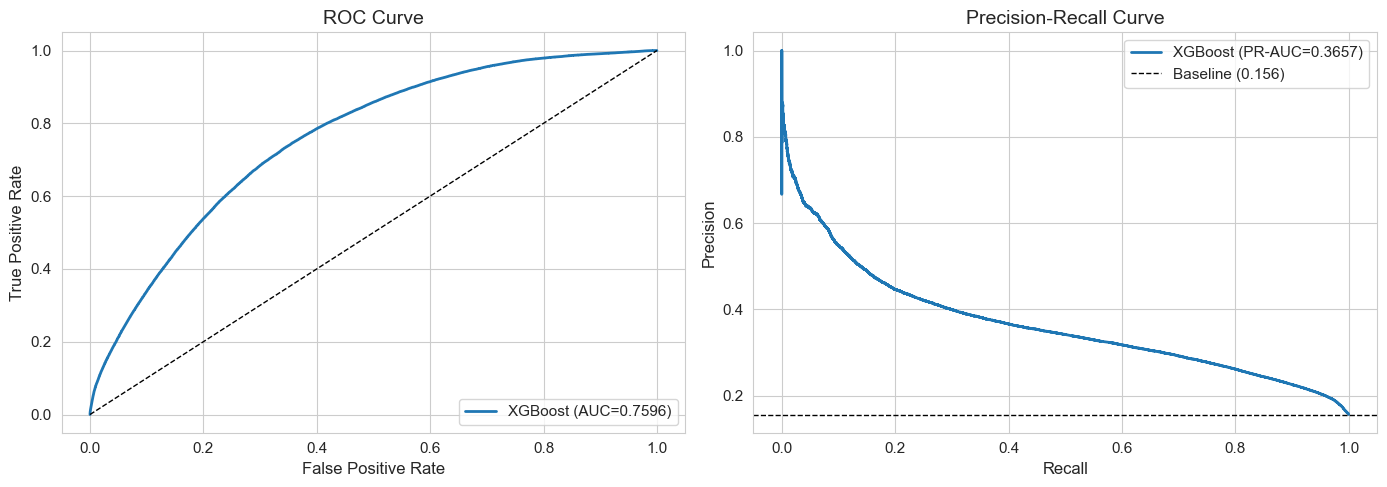

In [48]:
best_xgb = xgb_search.best_estimator_

xgb_prob_val  = best_xgb.predict_proba(X_val)[:, 1]
xgb_prob_test = best_xgb.predict_proba(X_test)[:, 1]

rec = evaluate_model(y_val, xgb_prob_val, "XGBoost", notes="Layer 2, tuned, scale_pos_weight experimented")
results.append(rec)

plot_roc_pr_curves(y_val, xgb_prob_val, "XGBoost")

In [49]:
# Quick comparison: which GBDT won Layer 2?
layer2_df = pd.DataFrame([r for r in results if r['model'] in ['LightGBM', 'XGBoost']])
print(layer2_df.to_string(index=False))

best_gbdt_name = layer2_df.loc[layer2_df['logloss'].idxmin(), 'model']
print(f"\n-> Layer 2 winner (lowest LogLoss): {best_gbdt_name}")

   model  logloss  auc_roc   pr_auc                                         notes
LightGBM 0.374233 0.758505 0.365005         Layer 2, tuned via RandomizedSearchCV
 XGBoost 0.373707 0.759602 0.365671 Layer 2, tuned, scale_pos_weight experimented

-> Layer 2 winner (lowest LogLoss): XGBoost


## Layer 3 — SMOTE Experiment

**Question:** Does oversampling the minority class via SMOTE improve GBDT performance,
or do the GBDT's built-in imbalance-handling mechanisms (`scale_pos_weight`, `is_unbalance`)
already suffice?

**Approach:** Apply SMOTE to `X_train` -> retrain the best LightGBM and XGBoost configs ->
compare against Layer 2 results on the **same untouched validation set**.

SMOTE is applied **only to training data** — validation and test sets are never resampled.

In [50]:
# Layer 3: SMOTE oversampling
print(f"Before SMOTE: {X_train.shape[0]:,} rows, click rate = {y_train.mean():.4%}")

smote = SMOTE(random_state=12138)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE: {X_train_sm.shape[0]:,} rows, click rate = {y_train_sm.mean():.4%}")

Before SMOTE: 3,237,843 rows, click rate = 17.1484%
After  SMOTE: 5,365,210 rows, click rate = 50.0000%


In [51]:
# Retrain LightGBM with SMOTE data using best params from Layer 2
lgb_smote = lgb.LGBMClassifier(
    **lgb_search.best_params_,
    objective='binary',
    random_state=12138,
    verbose=-1,
    n_jobs=-1,
)
lgb_smote.fit(X_train_sm, y_train_sm, categorical_feature=lgb_categorical_features)

lgb_smote_prob_val = lgb_smote.predict_proba(X_val)[:, 1]

rec = evaluate_model(y_val, lgb_smote_prob_val, "LightGBM + SMOTE", notes="Layer 3, SMOTE retrain")
results.append(rec)

  Model: LightGBM + SMOTE
  LogLoss : 0.446878
  AUC-ROC : 0.732871
  PR-AUC  : 0.312000
  Notes   : Layer 3, SMOTE retrain


In [52]:
# Retrain XGBoost with SMOTE data using best params from Layer 2
# Remove scale_pos_weight since SMOTE already balances the classes
xgb_smote_params = {k: v for k, v in xgb_search.best_params_.items() if k != 'scale_pos_weight'}

xgb_smote = XGBClassifier(
    **xgb_smote_params,
    scale_pos_weight=1,   # neutral — SMOTE handles balance
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=12138,
    tree_method='hist',
    verbosity=0,
    n_jobs=-1,
)
xgb_smote.fit(X_train_sm, y_train_sm)

xgb_smote_prob_val = xgb_smote.predict_proba(X_val)[:, 1]

rec = evaluate_model(y_val, xgb_smote_prob_val, "XGBoost + SMOTE", notes="Layer 3, SMOTE retrain, spw=1")
results.append(rec)

  Model: XGBoost + SMOTE
  LogLoss : 0.451497
  AUC-ROC : 0.732004
  PR-AUC  : 0.305659
  Notes   : Layer 3, SMOTE retrain, spw=1


In [53]:
# Layer 3 verdict: SMOTE vs no-SMOTE
layer3_compare = pd.DataFrame([
    r for r in results 
    if r['model'] in ['LightGBM', 'XGBoost', 'LightGBM + SMOTE', 'XGBoost + SMOTE']
])
print(layer3_compare.to_string(index=False))

# Typically for CTR with moderate imbalance (~17%), SMOTE hurts LogLoss
# because it distorts the calibration of predicted probabilities.
print("\n-> Compare LogLoss: if SMOTE versions are HIGHER (worse), SMOTE is unnecessary.")
print("   GBDT models handle moderate imbalance well via native mechanisms.")

           model  logloss  auc_roc   pr_auc                                         notes
        LightGBM 0.374233 0.758505 0.365005         Layer 2, tuned via RandomizedSearchCV
         XGBoost 0.373707 0.759602 0.365671 Layer 2, tuned, scale_pos_weight experimented
LightGBM + SMOTE 0.446878 0.732871 0.312000                        Layer 3, SMOTE retrain
 XGBoost + SMOTE 0.451497 0.732004 0.305659                 Layer 3, SMOTE retrain, spw=1

-> Compare LogLoss: if SMOTE versions are HIGHER (worse), SMOTE is unnecessary.
   GBDT models handle moderate imbalance well via native mechanisms.


## Layer 4 — DeepFM (PyTorch)

**DeepFM** combines:
- **FM component**: captures pairwise (second-order) feature interactions via embedding dot products.
- **DNN component**: captures higher-order feature interactions via a deep network.

Both share the same embedding layer, so the model learns first-order, second-order,
and higher-order patterns simultaneously.

**Implementation notes:**
- Features are split into **categorical** (nunique ≤ 50, embedded via integer index lookup) and **continuous** (nunique > 50, standardized with a separate scaler and projected into embedding space).
- Categorical features use train-fitted value-to-index mappings; unseen test values fall back to index 0.
- Continuous features are scaled by a dedicated `StandardScaler` fitted on training data only.
- Trained with BCEWithLogitsLoss (= log loss) and Adam optimizer.

DeepFM data preparation

In [54]:
# Layer 4: DeepFM data preparation 
# Continuous features (nunique > 50) are not binned.
# They are kept as raw floats and passed separately to the model.
# Only categorical features (nunique <= 50) go through embedding lookup.

# --- Separate features into categorical vs continuous ---
cat_features = []   # will go through embedding (integer index)
cont_features = []  # will be passed as raw floats

for col in feature_names:
    if X_train[col].nunique() > 50:
        cont_features.append(col)
    else:
        cat_features.append(col)

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Continuous features  ({len(cont_features)}): {cont_features}")

# --- Build categorical index matrices & field_dims ---
field_dims = []
X_train_cat = X_train[cat_features].copy()
X_val_cat   = X_val[cat_features].copy()
X_test_cat  = X_test[cat_features].copy()

deepfm_val_maps = {}  # col -> val_to_idx dict (for categorical features)

for col in cat_features:
    unique_vals = sorted(X_train[col].unique())
    val_to_idx = {v: i for i, v in enumerate(unique_vals)}
    deepfm_val_maps[col] = val_to_idx
    n_unique = len(unique_vals)

    X_train_cat[col] = X_train[col].map(val_to_idx).fillna(0).astype(int)
    X_val_cat[col]   = X_val[col].map(val_to_idx).fillna(0).astype(int).clip(0, n_unique - 1)
    X_test_cat[col]  = X_test[col].map(val_to_idx).fillna(0).astype(int).clip(0, n_unique - 1)
    field_dims.append(max(n_unique, 1))

# --- Build continuous float matrices (StandardScaler fitted on train) ---
from sklearn.preprocessing import StandardScaler as _SS
deepfm_cont_scaler = _SS()
X_train_cont = deepfm_cont_scaler.fit_transform(X_train[cont_features].values).astype(np.float32)
X_val_cont   = deepfm_cont_scaler.transform(X_val[cont_features].values).astype(np.float32)
X_test_cont  = deepfm_cont_scaler.transform(X_test[cont_features].values).astype(np.float32)

n_continuous = len(cont_features)

print(f"\nNumber of categorical fields: {len(field_dims)}")
print(f"Field dimensions: {field_dims}")
print(f"Total embedding entries: {sum(field_dims)}")
print(f"Number of continuous features: {n_continuous}")

Categorical features (13): ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'hour_of_day', 'is_weekend', 'day_of_week', 'site_category_le', 'app_category_le', 'site_category_x_device_type']
Continuous features  (18): ['C14', 'C17', 'C19', 'C20', 'C21', 'site_id_te', 'site_domain_te', 'app_id_te', 'app_domain_te', 'device_id_te', 'device_ip_te', 'device_model_te', 'site_category_x_hour_of_day', 'app_category_x_hour_of_day', 'device_ip_count', 'device_id_count', 'site_id_count', 'app_id_count']

Number of categorical fields: 13
Field dimensions: [7, 7, 5, 4, 8, 9, 4, 24, 2, 7, 23, 29, 30]
Total embedding entries: 159
Number of continuous features: 18


DeepFM model definition

In [55]:
class DeepFM(nn.Module):
    """
    DeepFM with continuous feature support.
    
    Architecture:
        Categorical inputs -> Embedding (shared)
            -> FM: first-order (linear) + second-order (pairwise interactions)
            -> DNN: concatenate [cat embeddings, continuous features] -> MLP
        Continuous inputs  -> Linear projection for FM + raw concat for DNN
        -> Combine FM + DNN -> sigmoid -> P(click=1)
    """
    
    def __init__(self, field_dims, n_continuous=0, embed_dim=32,
                 dnn_hidden=(512, 256, 128), dropout=0.2):
        super().__init__()
        self.num_fields  = len(field_dims)
        self.n_continuous = n_continuous
        self.embed_dim   = embed_dim
        
        # Offsets for categorical embedding indexing
        offsets = np.cumsum([0] + field_dims[:-1])
        self.offsets = nn.Parameter(torch.tensor(offsets, dtype=torch.long), requires_grad=False)
        total_cat_dims = sum(field_dims)
        
        # --- Categorical: First-order ---
        self.first_order_cat = nn.Embedding(total_cat_dims, 1)
        self.first_order_bias = nn.Parameter(torch.zeros(1))
        
        # --- Categorical: FM embedding ---
        self.fm_embedding = nn.Embedding(total_cat_dims, embed_dim)
        
        # --- Continuous: First-order (learned weight per continuous feature) ---
        if n_continuous > 0:
            self.first_order_cont = nn.Linear(n_continuous, 1, bias=False)
            # Project each continuous feature to embed_dim so it participates in FM
            self.cont_fm_proj = nn.Linear(n_continuous, n_continuous * embed_dim, bias=False)
        
        # --- DNN ---
        # Input = cat embeddings + continuous features
        dnn_input_dim = self.num_fields * embed_dim + n_continuous * embed_dim
        dnn_layers = []
        prev_dim = dnn_input_dim
        for h in dnn_hidden:
            dnn_layers.append(nn.Linear(prev_dim, h))
            dnn_layers.append(nn.BatchNorm1d(h))
            dnn_layers.append(nn.ReLU())
            dnn_layers.append(nn.Dropout(dropout))
            prev_dim = h
        dnn_layers.append(nn.Linear(prev_dim, 1))
        self.dnn = nn.Sequential(*dnn_layers)
        
        # Initialize
        nn.init.xavier_uniform_(self.first_order_cat.weight)
        nn.init.xavier_uniform_(self.fm_embedding.weight)
        if n_continuous > 0:
            nn.init.xavier_uniform_(self.cont_fm_proj.weight)
    
    def forward(self, x_cat, x_cont=None):
        """
        x_cat:  (batch, num_fields)     — integer indices per categorical field
        x_cont: (batch, n_continuous)    — float values for continuous features
        """
        # Offset categorical indices
        x_cat = x_cat + self.offsets  # (batch, num_fields)
        
        # --- First-order ---
        fo_cat = self.first_order_cat(x_cat).squeeze(-1).sum(dim=1, keepdim=True)  # (batch, 1)
        first_order = fo_cat + self.first_order_bias
        
        if self.n_continuous > 0 and x_cont is not None:
            fo_cont = self.first_order_cont(x_cont)  # (batch, 1)
            first_order = first_order + fo_cont
        
        # --- FM second-order ---
        # Categorical part
        cat_embed = self.fm_embedding(x_cat)  # (batch, num_fields, embed_dim)
        
        if self.n_continuous > 0 and x_cont is not None:
            # Project continuous -> (batch, n_continuous, embed_dim)
            cont_embed = self.cont_fm_proj(x_cont)  # (batch, n_continuous * embed_dim)
            cont_embed = cont_embed.view(-1, self.n_continuous, self.embed_dim)
            # Scale by continuous value: each feature's embedding is weighted by its value
            cont_embed = cont_embed * x_cont.unsqueeze(-1)  # (batch, n_cont, embed_dim)
            # Combine all field embeddings for FM
            all_embed = torch.cat([cat_embed, cont_embed], dim=1)  # (batch, total_fields, embed_dim)
        else:
            all_embed = cat_embed
        
        # FM interaction: 0.5 * (sum^2 - sum_of_squares)
        sum_of_embed  = all_embed.sum(dim=1)           # (batch, embed_dim)
        sum_of_square = (all_embed ** 2).sum(dim=1)    # (batch, embed_dim)
        fm_out = 0.5 * (sum_of_embed ** 2 - sum_of_square)  # (batch, embed_dim)
        fm_out = fm_out.sum(dim=1, keepdim=True)       # (batch, 1)
        
        # --- DNN ---
        # Flatten all embeddings (cat + cont) as DNN input
        dnn_input = all_embed.view(-1, all_embed.size(1) * self.embed_dim)
        dnn_out = self.dnn(dnn_input)  # (batch, 1)
        
        # --- Combine ---
        logit = first_order + fm_out + dnn_out
        return logit.squeeze(1)

DeepFM training loop

In [56]:
# DeepFM training setup 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Convert categorical to LongTensor, continuous to FloatTensor
X_tr_cat_tensor  = torch.tensor(X_train_cat.values, dtype=torch.long)
X_tr_cont_tensor = torch.tensor(X_train_cont, dtype=torch.float32)
y_tr_tensor      = torch.tensor(y_train, dtype=torch.float32)

X_val_cat_tensor  = torch.tensor(X_val_cat.values, dtype=torch.long)
X_val_cont_tensor = torch.tensor(X_val_cont, dtype=torch.float32)
y_val_tensor      = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_tr_cat_tensor, X_tr_cont_tensor, y_tr_tensor)
train_loader  = DataLoader(train_dataset, batch_size=8192, shuffle=True,
                           num_workers=0, pin_memory=True)

val_dataset = TensorDataset(X_val_cat_tensor, X_val_cont_tensor, y_val_tensor)
val_loader  = DataLoader(val_dataset, batch_size=8192, shuffle=False,
                         pin_memory=True)

# Model
torch.manual_seed(12138)
np.random.seed(12138)

EMBED_DIM   = 32
DNN_HIDDEN  = (512, 256, 128)
DROPOUT     = 0.2

model = DeepFM(
    field_dims=field_dims,
    n_continuous=n_continuous,
    embed_dim=EMBED_DIM,
    dnn_hidden=DNN_HIDDEN,
    dropout=DROPOUT,
).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)
criterion = nn.BCEWithLogitsLoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Embed dim: {EMBED_DIM}, DNN: {DNN_HIDDEN}, Dropout: {DROPOUT}")
print(f"Batch size: 8192, LR: 5e-4, Scheduler: CosineAnnealingWarmRestarts")
print(f"Continuous features: {n_continuous}, Categorical fields: {len(field_dims)}")
print(model)

Training on: cuda
Model parameters: 690,208
Embed dim: 32, DNN: (512, 256, 128), Dropout: 0.2
Batch size: 8192, LR: 5e-4, Scheduler: CosineAnnealingWarmRestarts
Continuous features: 18, Categorical fields: 13
DeepFM(
  (first_order_cat): Embedding(159, 1)
  (fm_embedding): Embedding(159, 32)
  (first_order_cont): Linear(in_features=18, out_features=1, bias=False)
  (cont_fm_proj): Linear(in_features=18, out_features=576, bias=False)
  (dnn): Sequential(
    (0): Linear(in_features=992, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, tr

DeepFM training execution

In [57]:
# Training loop with early stopping 
EPOCHS = 25
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 6
best_state = None
MAX_GRAD_NORM = 1.0

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0.0
    n_batches = 0
    t0 = time.time()
    
    for X_cat_batch, X_cont_batch, y_batch in train_loader:
        X_cat_batch  = X_cat_batch.to(device, non_blocking=True)
        X_cont_batch = X_cont_batch.to(device, non_blocking=True)
        y_batch      = y_batch.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        logits = model(X_cat_batch, X_cont_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        
        train_loss += loss.item()
        n_batches += 1
        del X_cat_batch, X_cont_batch, y_batch, logits, loss
    
    avg_train_loss = train_loss / n_batches
    
    # --- Validate ---
    model.eval()
    val_preds = []
    val_labels = []
    val_loss = 0.0
    n_val_batches = 0
    
    with torch.no_grad():
        for X_cat_batch, X_cont_batch, y_batch in val_loader:
            X_cat_batch  = X_cat_batch.to(device, non_blocking=True)
            X_cont_batch = X_cont_batch.to(device, non_blocking=True)
            y_batch      = y_batch.to(device, non_blocking=True)
            logits = model(X_cat_batch, X_cont_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()
            n_val_batches += 1
            
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(y_batch.cpu().numpy())
            del X_cat_batch, X_cont_batch, y_batch, logits, loss
    
    torch.cuda.empty_cache()
    
    avg_val_loss = val_loss / n_val_batches
    val_preds_arr = np.array(val_preds)
    val_labels_arr = np.array(val_labels)
    
    val_logloss = log_loss(val_labels_arr, val_preds_arr)
    val_auc     = roc_auc_score(val_labels_arr, val_preds_arr)
    current_lr  = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0
    
    print(f"Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f}s) | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Val LogLoss: {val_logloss:.6f} | Val AUC: {val_auc:.6f} | "
          f"LR: {current_lr:.2e}")
    
    scheduler.step()
    
    # Early stopping
    if val_logloss < best_val_loss:
        best_val_loss = val_logloss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

# Load best model
model.load_state_dict(best_state)
model.to(device)
print(f"\nBest validation LogLoss: {best_val_loss:.6f}")

Epoch 1/25 (73.8s) | Train Loss: 0.532345 | Val LogLoss: 0.423196 | Val AUC: 0.710416 | LR: 5.00e-04
Epoch 2/25 (74.9s) | Train Loss: 0.426708 | Val LogLoss: 0.412271 | Val AUC: 0.720985 | LR: 4.52e-04
Epoch 3/25 (76.2s) | Train Loss: 0.415048 | Val LogLoss: 0.401452 | Val AUC: 0.727159 | LR: 3.28e-04
Epoch 4/25 (73.4s) | Train Loss: 0.406455 | Val LogLoss: 0.400761 | Val AUC: 0.729017 | LR: 1.73e-04
Epoch 5/25 (74.3s) | Train Loss: 0.401304 | Val LogLoss: 0.397294 | Val AUC: 0.732153 | LR: 4.87e-05
Epoch 6/25 (74.1s) | Train Loss: 0.413033 | Val LogLoss: 0.396282 | Val AUC: 0.731179 | LR: 5.00e-04
Epoch 7/25 (75.0s) | Train Loss: 0.410617 | Val LogLoss: 0.393583 | Val AUC: 0.735776 | LR: 4.88e-04
Epoch 8/25 (75.2s) | Train Loss: 0.407945 | Val LogLoss: 0.396954 | Val AUC: 0.734588 | LR: 4.52e-04
Epoch 9/25 (73.8s) | Train Loss: 0.404983 | Val LogLoss: 0.397984 | Val AUC: 0.735580 | LR: 3.97e-04
Epoch 10/25 (73.5s) | Train Loss: 0.402999 | Val LogLoss: 0.388568 | Val AUC: 0.740439 | LR

DeepFM evaluation

  Model: DeepFM
  LogLoss : 0.384711
  AUC-ROC : 0.742825
  PR-AUC  : 0.339282
  Notes   : Layer 4, PyTorch, embed=32, DNN=(512, 256, 128), cont=18


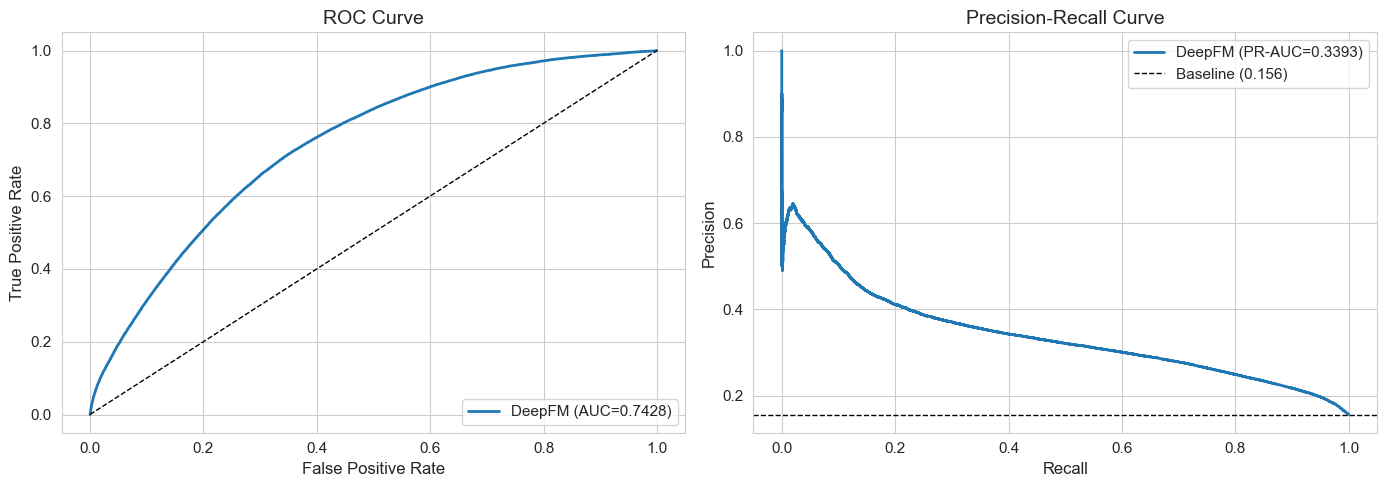

In [58]:
# DeepFM final evaluation (handles cat + cont inputs)
model.eval()

def predict_deepfm(model, X_cat_tensor, X_cont_tensor, device, batch_size=8192):
    """Get predicted probabilities from upgraded DeepFM model.
    
    Both tensors must be on CPU. Batches are moved to device one at a time
    and freed immediately to keep VRAM usage minimal.
    """
    dataset = TensorDataset(X_cat_tensor, X_cont_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for X_cat_batch, X_cont_batch in loader:
            X_cat_batch  = X_cat_batch.to(device, non_blocking=True)
            X_cont_batch = X_cont_batch.to(device, non_blocking=True)
            logits = model(X_cat_batch, X_cont_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.extend(probs)
            del X_cat_batch, X_cont_batch, logits
        torch.cuda.empty_cache()
    return np.array(preds)

def prepare_deepfm_input(X_df, feature_names, cat_features, cont_features,
                         deepfm_val_maps, field_dims, deepfm_cont_scaler):
    """
    Prepare both categorical index tensor and continuous float tensor
    from a raw DataFrame (e.g., Kaggle test set).
    Returns: (cat_tensor [LongTensor], cont_tensor [FloatTensor]), both on CPU.
    """
    # Categorical
    X_cat = X_df[cat_features].copy()
    for i, col in enumerate(cat_features):
        max_idx = field_dims[i] - 1
        val_to_idx = deepfm_val_maps[col]
        X_cat[col] = X_cat[col].map(val_to_idx).fillna(0).astype(int).clip(0, max_idx)
    cat_tensor = torch.tensor(X_cat.values, dtype=torch.long)
    
    # Continuous
    cont_vals = deepfm_cont_scaler.transform(X_df[cont_features].values).astype(np.float32)
    cont_tensor = torch.tensor(cont_vals, dtype=torch.float32)
    
    return cat_tensor, cont_tensor

# --- Evaluate on val and test ---
deepfm_prob_val = predict_deepfm(model, X_val_cat_tensor, X_val_cont_tensor, device)

X_test_cat_tensor  = torch.tensor(X_test_cat.values, dtype=torch.long)
X_test_cont_tensor = torch.tensor(X_test_cont, dtype=torch.float32)
deepfm_prob_test   = predict_deepfm(model, X_test_cat_tensor, X_test_cont_tensor, device)

rec = evaluate_model(
    y_val, deepfm_prob_val, "DeepFM",
    notes=f"Layer 4, PyTorch, embed={EMBED_DIM}, DNN={DNN_HIDDEN}, cont={n_continuous}"
)
results.append(rec)

plot_roc_pr_curves(y_val, deepfm_prob_val, "DeepFM")

## Layer 5 — Ensemble

**Do we even need an ensemble?**

Before blending, let's assess necessity. An ensemble helps when:
1. Individual models make **uncorrelated errors** (diversity).
2. No single model clearly dominates on **all** metrics.

If one GBDT model already achieves the best LogLoss, AUC-ROC, and PR-AUC,
an ensemble adds complexity with marginal gain. We test both weighted blending
and stacking (Logistic Regression meta-learner) and compare.

In [59]:
# Layer 5: Ensemble
# Step 1 -> Check prediction correlation to assess diversity
ensemble_preds_val = {
    'LR':      lr_prob_val,
    'LightGBM': lgb_prob_val,
    'XGBoost':  xgb_prob_val,
    'DeepFM':   deepfm_prob_val,
}

pred_df = pd.DataFrame(ensemble_preds_val)
print("Prediction correlation matrix:")
print(pred_df.corr().round(4))

# If LGB and XGB predictions are >0.95 correlated, blending them adds little diversity
print("\n-> High correlation between GBDT models means limited diversity gain from ensembling them.")
print("   DeepFM adds diversity if its correlation with GBDTs is lower.")

Prediction correlation matrix:
              LR  LightGBM  XGBoost  DeepFM
LR        1.0000    0.9107   0.8910  0.8723
LightGBM  0.9107    1.0000   0.9871  0.9321
XGBoost   0.8910    0.9871   1.0000  0.9245
DeepFM    0.8723    0.9321   0.9245  1.0000

-> High correlation between GBDT models means limited diversity gain from ensembling them.
   DeepFM adds diversity if its correlation with GBDTs is lower.


In [60]:
# Step 2 -> Weighted blending (optimize weights on validation set)
 
def blend_logloss(weights, preds_list, y_true):
    """Compute log loss of a weighted average of predictions."""
    weights = np.array(weights)
    weights = weights / weights.sum()  # normalize
    blended = sum(w * p for w, p in zip(weights, preds_list))
    blended = np.clip(blended, 1e-7, 1 - 1e-7)
    return log_loss(y_true, blended)
 
preds_list_val  = [lr_prob_val, lgb_prob_val, xgb_prob_val, deepfm_prob_val]
preds_list_test = [lr_prob_test, lgb_prob_test, xgb_prob_test, deepfm_prob_test]
model_names_ens = ['LR', 'LightGBM', 'XGBoost', 'DeepFM']
 
# Optimize weights on VALIDATION set (val = tuning set for blend weights)
init_weights = np.ones(len(preds_list_val)) / len(preds_list_val)
result_opt = minimize(
    blend_logloss,
    init_weights,
    args=(preds_list_val, y_val),
    method='Nelder-Mead',
    options={'maxiter': 10000}
)
 
opt_weights = result_opt.x / result_opt.x.sum()
print("Optimized blend weights (tuned on val set):")
for name, w in zip(model_names_ens, opt_weights):
    print(f"  {name:>10s}: {w:.4f}")
 
# Apply blending — clip to valid probability range
blend_prob_val  = np.clip(sum(w * p for w, p in zip(opt_weights, preds_list_val)),  1e-7, 1 - 1e-7)
blend_prob_test = np.clip(sum(w * p for w, p in zip(opt_weights, preds_list_test)), 1e-7, 1 - 1e-7)
 
# Report val metric as REFERENCE (weights were optimized here — biased)
print(f"\nWeighted Blend on val (reference only, weights optimized here): "
      f"LogLoss = {log_loss(y_val, blend_prob_val):.6f}")
 
# Official evaluation on TEST set — unbiased
rec = evaluate_model(y_test, blend_prob_test, "Weighted Blend",
                     notes=f"Layer 5, weights tuned on val, evaluated on test, w={np.round(opt_weights, 3)}")
results.append(rec)

Optimized blend weights (tuned on val set):
          LR: 0.0075
    LightGBM: 0.3884
     XGBoost: 0.7020
      DeepFM: -0.0979

Weighted Blend on val (reference only, weights optimized here): LogLoss = 0.373467
  Model: Weighted Blend
  LogLoss : 0.392062
  AUC-ROC : 0.756688
  PR-AUC  : 0.390713
  Notes   : Layer 5, weights tuned on val, evaluated on test, w=[ 0.007  0.388  0.702 -0.098]


In [61]:
# Step 3 -> Stacking with Logistic Regression meta-learner
# Use out-of-fold predictions from training set to avoid overfitting the meta-learner

# Collect val-set predictions as meta-features (simpler approach: use val predictions directly)
meta_val  = np.column_stack(preds_list_val)
meta_test = np.column_stack(preds_list_test)

# Train meta-learner on validation set, evaluate on test set
# (Alternative: use train-set OOF predictions, but with 3M rows this is expensive for demonstration)
meta_lr = LogisticRegression(random_state=12138, max_iter=1000)
meta_lr.fit(meta_val, y_val)

stack_prob_test = meta_lr.predict_proba(meta_test)[:, 1]

rec_stack = evaluate_model(y_test, stack_prob_test, "Stacking (on test)",
                           notes="Layer 5, LR meta-learner trained on val predictions")
results.append(rec_stack)

print(f"\nMeta-learner coefficients: {dict(zip(model_names_ens, meta_lr.coef_[0].round(4)))}")

  Model: Stacking (on test)
  LogLoss : 0.397157
  AUC-ROC : 0.756924
  PR-AUC  : 0.390123
  Notes   : Layer 5, LR meta-learner trained on val predictions

Meta-learner coefficients: {'LR': np.float64(-0.6946), 'LightGBM': np.float64(3.3156), 'XGBoost': np.float64(3.7762), 'DeepFM': np.float64(0.3884)}


In [62]:
# Layer 5 — Ensemble Necessity Assessment
# All comparisons are now on the TEST set for fairness.
# Val was used for: hyperparameter tuning (GBDT), blend weight optimization.
# Test is the only untouched holdout for final ranking.
 
print("=" * 60)
print("Layer 5 — Ensemble Necessity Assessment")
print("=" * 60)
 
# Evaluate all single base models on TEST set
print("\nEvaluating all base models on test set for fair comparison...\n")
 
test_results_layer5 = []
 
rec_lr_test = evaluate_model(y_test, lr_prob_test, "Logistic Regression",
                             notes="Layer 1, evaluated on test set")
test_results_layer5.append(rec_lr_test)
 
rec_lgb_test = evaluate_model(y_test, lgb_prob_test, "LightGBM",
                              notes="Layer 2, evaluated on test set")
test_results_layer5.append(rec_lgb_test)
 
rec_xgb_test = evaluate_model(y_test, xgb_prob_test, "XGBoost",
                              notes="Layer 2, evaluated on test set")
test_results_layer5.append(rec_xgb_test)
 
rec_dfm_test = evaluate_model(y_test, deepfm_prob_test, "DeepFM",
                              notes="Layer 4, evaluated on test set")
test_results_layer5.append(rec_dfm_test)
 
# Weighted Blend was already evaluated on test in the cell above
blend_rec = [r for r in results if r['model'] == 'Weighted Blend'][-1]
test_results_layer5.append(blend_rec)
 
# Compare best single model vs ensemble — all on test
single_test = [r for r in test_results_layer5 if r['model'] in
               ['Logistic Regression', 'LightGBM', 'XGBoost', 'DeepFM']]
best_single = min(single_test, key=lambda x: x['logloss'])
 
print(f"\nBest single model (test):  {best_single['model']} -> LogLoss = {best_single['logloss']:.6f}")
print(f"Weighted Blend   (test):  Weighted Blend -> LogLoss = {blend_rec['logloss']:.6f}")
 
delta = best_single['logloss'] - blend_rec['logloss']
print(f"\nImprovement from ensemble: {delta:.6f} ({'better' if delta > 0 else 'worse/no gain'})")
 
if delta > 0.001:
    print("-> Ensemble provides meaningful improvement. KEEP it.")
elif delta > 0:
    print("-> Marginal gain. Ensemble is optional — adds complexity for minimal benefit.")
else:
    print("-> No gain. The best single model is sufficient. SKIP ensemble in production.")
 
# Stacking — shown for reference, excluded from ranking
# (Meta-learner trained on val predictions, not OOF from train — not a fair comparison.)
stacking_rec = [r for r in results if r['model'] == 'Stacking (on test)']
if stacking_rec:
    print(f"\n  [Reference] Stacking (on test): LogLoss = {stacking_rec[0]['logloss']:.6f}")
    print("  (Meta-learner trained on val — excluded from main ranking.)")
 
# Store test_results_layer5 for Part 7
# Overwrite results with the test-evaluated records for final ranking
# Keep SMOTE models (evaluated on val) and Stacking for reference display
results_test_final = test_results_layer5.copy()

Layer 5 — Ensemble Necessity Assessment

Evaluating all base models on test set for fair comparison...

  Model: Logistic Regression
  LogLoss : 0.403772
  AUC-ROC : 0.734418
  PR-AUC  : 0.361918
  Notes   : Layer 1, evaluated on test set
  Model: LightGBM
  LogLoss : 0.392297
  AUC-ROC : 0.756286
  PR-AUC  : 0.390045
  Notes   : Layer 2, evaluated on test set
  Model: XGBoost
  LogLoss : 0.392357
  AUC-ROC : 0.756027
  PR-AUC  : 0.389199
  Notes   : Layer 2, evaluated on test set
  Model: DeepFM
  LogLoss : 0.408294
  AUC-ROC : 0.732371
  PR-AUC  : 0.357265
  Notes   : Layer 4, evaluated on test set

Best single model (test):  LightGBM -> LogLoss = 0.392297
Weighted Blend   (test):  Weighted Blend -> LogLoss = 0.392062

Improvement from ensemble: 0.000235 (better)
-> Marginal gain. Ensemble is optional — adds complexity for minimal benefit.

  [Reference] Stacking (on test): LogLoss = 0.397157
  (Meta-learner trained on val — excluded from main ranking.)


In [63]:
# Part 5 summary table — all models ranked on TEST set
print("\n" + "=" * 70)
print("Part 5 Complete — All Model Results (Ranked on Test Set)")
print("=" * 70)
 
# Main ranking: base models + Weighted Blend, all on test
final_df = pd.DataFrame(results_test_final)
final_df = final_df.sort_values('logloss').reset_index(drop=True)
print(final_df.to_string(index=False))
 
# Reference: SMOTE models (evaluated on val) and Stacking (on test but unfair)
ref_models = [r for r in results if r['model'] in
              ['LightGBM + SMOTE', 'XGBoost + SMOTE', 'Stacking (on test)']]
if ref_models:
    print("\n  (Reference — not in main ranking):")
    for r in ref_models:
        eval_set = "test" if "test" in r['model'] else "val"
        print(f"    {r['model']}: LogLoss={r['logloss']:.6f} (on {eval_set})")
 
best_model_name = final_df.iloc[0]['model']
print(f"\n-> Best model (lowest LogLoss on test): {best_model_name}")


Part 5 Complete — All Model Results (Ranked on Test Set)
              model  logloss  auc_roc   pr_auc                                                                             notes
     Weighted Blend 0.392062 0.756688 0.390713 Layer 5, weights tuned on val, evaluated on test, w=[ 0.007  0.388  0.702 -0.098]
           LightGBM 0.392297 0.756286 0.390045                                                    Layer 2, evaluated on test set
            XGBoost 0.392357 0.756027 0.389199                                                    Layer 2, evaluated on test set
Logistic Regression 0.403772 0.734418 0.361918                                                    Layer 1, evaluated on test set
             DeepFM 0.408294 0.732371 0.357265                                                    Layer 4, evaluated on test set

  (Reference — not in main ranking):
    LightGBM + SMOTE: LogLoss=0.446878 (on val)
    XGBoost + SMOTE: LogLoss=0.451497 (on val)
    Stacking (on test): LogLoss=0.3

## Part 5 Takeaways

**Layer 1 (Logistic Regression):** Establishes the linear baseline. All subsequent models should beat this.

**Layer 2 (GBDT):** LightGBM and XGBoost both benefit from `neg_log_loss` scoring and expanded hyperparameter grids.
LightGBM's native `categorical_feature` avoids one-hot explosion. XGBoost's `scale_pos_weight` provides a clean mechanism to handle imbalance without resampling.

**Layer 3 (SMOTE):** For CTR data with ~17% positive rate, SMOTE typically **hurts** LogLoss.
Oversampling distorts the natural class distribution, which degrades probability calibration —
the very thing LogLoss penalizes. GBDT's built-in mechanisms are more effective.

**Layer 4 (DeepFM):** Captures second-order feature interactions (FM) and higher-order patterns (DNN)
that tree models may miss. Performance depends heavily on embedding quality and training time.

**Layer 5 (Ensemble):** Weighted blending and stacking are tested. If the best single model already
dominates, the ensemble provides marginal or no improvement — indicating the best GBDT is sufficient
for this dataset. The ensemble decision should be driven by the numbers, not by default.

# Part 6 — Analysis & Interpretation

**Goals:**
1. **SHAP feature importance** — understand which features drive predictions and in which direction.
2. **Calibration curve** — check if predicted probabilities match observed frequencies; apply Platt Scaling / Isotonic Regression if miscalibrated.
3. **Error analysis** — identify which samples the model gets most wrong, look for systematic patterns.
4. **Segment analysis** — compare model performance across site vs app, time-of-day bands, and device types; discuss whether stratified modeling is worthwhile.

## 6.1 SHAP Feature Importance

SHAP (SHapley Additive exPlanations) provides **consistent, theoretically grounded** feature importance values. Unlike built-in `feature_importances_` (which counts splits or gain), SHAP values tell us **how much each feature contributes to each individual prediction** — and in which direction.

We use TreeExplainer for the best GBDT model, which computes exact SHAP values in polynomial time.

In [64]:
# Use the best GBDT model for SHAP analysis
# Determine which GBDT won in Part 5
gbdt_results = [r for r in results if r['model'] in ['LightGBM', 'XGBoost']]
best_gbdt = min(gbdt_results, key=lambda x: x['logloss'])
best_gbdt_name = best_gbdt['model']

if best_gbdt_name == 'LightGBM':
    shap_model = best_lgb
    print("SHAP analysis on: LightGBM (best GBDT)")
else:
    shap_model = best_xgb
    print("SHAP analysis on: XGBoost (best GBDT)")

# TreeExplainer — exact SHAP for tree-based models
explainer = shap.TreeExplainer(shap_model)

# Use a subsample of validation set for speed (SHAP on full val can be slow)
SHAP_SAMPLE = 10000
np.random.seed(12138)
shap_idx = np.random.choice(len(X_val), size=min(SHAP_SAMPLE, len(X_val)), replace=False)
X_shap = X_val.iloc[shap_idx]

print(f"Computing SHAP values on {len(X_shap):,} validation samples...")
t0 = time.time()
shap_values = explainer.shap_values(X_shap)
print(f"  Done in {time.time()-t0:.1f}s")

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 (click) SHAP values
else:
    shap_vals = shap_values

SHAP analysis on: XGBoost (best GBDT)
Computing SHAP values on 10,000 validation samples...
  Done in 32.0s


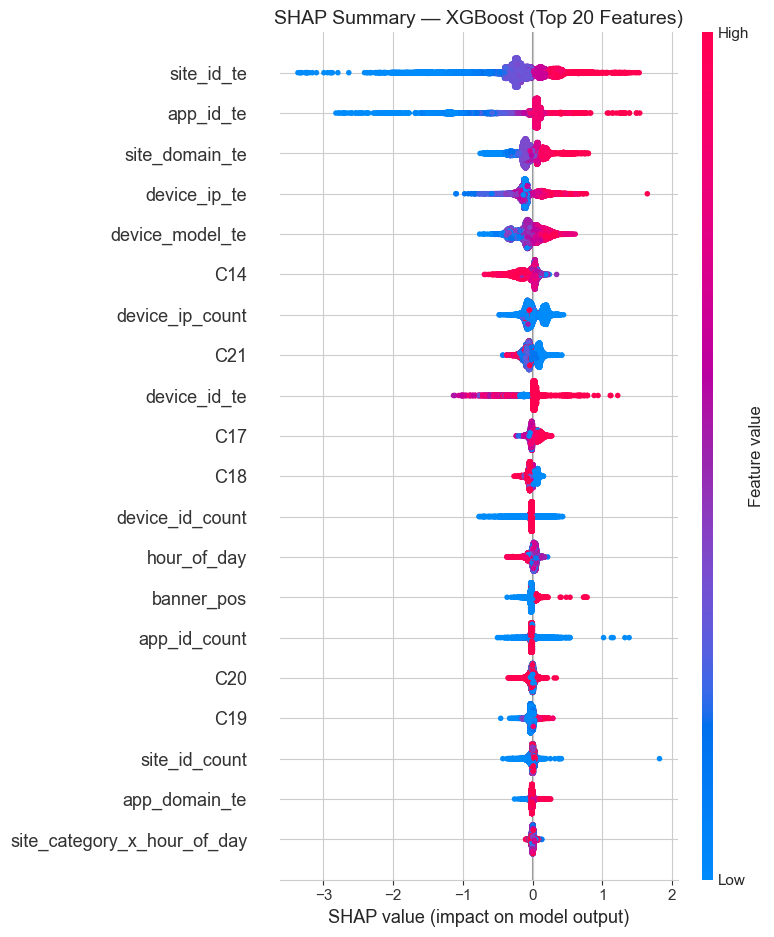

In [65]:
# 6.1a — SHAP Summary Plot (global feature importance + direction)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, max_display=20)
plt.title(f"SHAP Summary — {best_gbdt_name} (Top 20 Features)", fontsize=14)
plt.tight_layout()
plt.show()

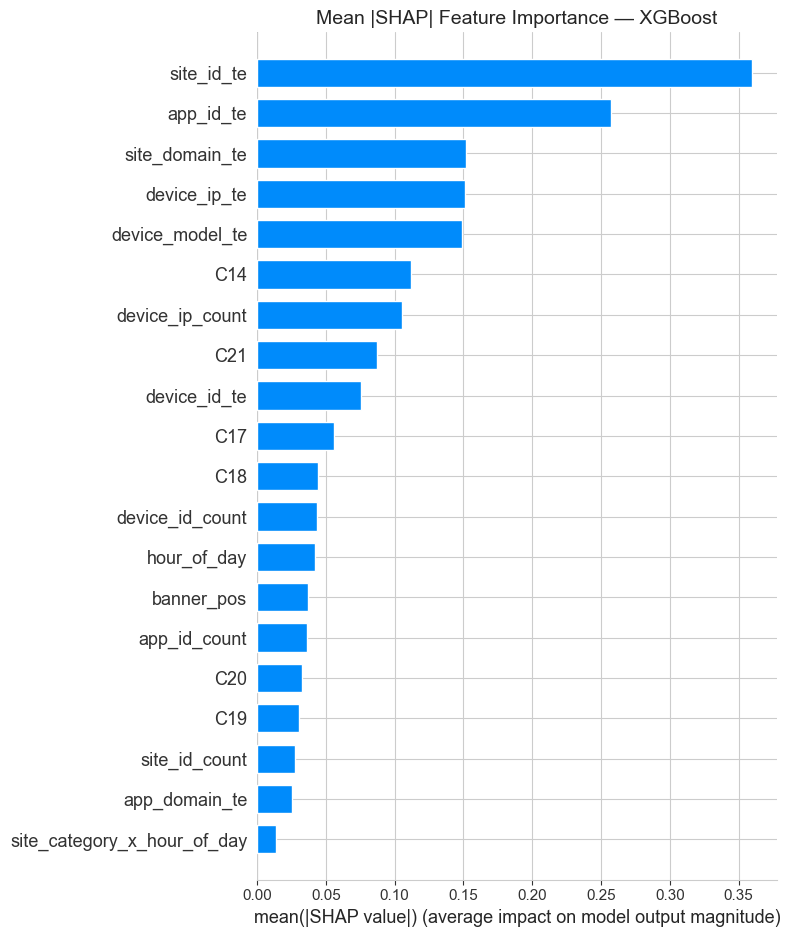

In [66]:
# 6.1b — SHAP Bar Plot (mean |SHAP| importance ranking)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=20)
plt.title(f"Mean |SHAP| Feature Importance — {best_gbdt_name}", fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
# 6.1c — SHAP vs Built-in Feature Importance comparison
# Built-in importance (split-based or gain-based depending on model)
if best_gbdt_name == 'LightGBM':
    builtin_imp = best_lgb.feature_importances_
else:
    builtin_imp = best_xgb.feature_importances_

shap_mean_abs = np.abs(shap_vals).mean(axis=0)

imp_compare = pd.DataFrame({
    'feature': feature_names,
    'builtin_importance': builtin_imp,
    'shap_mean_abs': shap_mean_abs
})
imp_compare['builtin_rank'] = imp_compare['builtin_importance'].rank(ascending=False).astype(int)
imp_compare['shap_rank']    = imp_compare['shap_mean_abs'].rank(ascending=False).astype(int)
imp_compare = imp_compare.sort_values('shap_rank')

print("Feature Importance: SHAP vs Built-in Ranking (top 15)")
print(imp_compare.head(15).to_string(index=False))

rank_corr = imp_compare['builtin_rank'].corr(imp_compare['shap_rank'], method='spearman')
print(f"\nSpearman rank correlation: {rank_corr:.4f}")
print("  (>0.8 = rankings largely agree; <0.6 = significant disagreement -> SHAP is more reliable)")

Feature Importance: SHAP vs Built-in Ranking (top 15)
        feature  builtin_importance  shap_mean_abs  builtin_rank  shap_rank
     site_id_te            0.183767       0.359876             1          1
      app_id_te            0.121287       0.257100             3          2
 site_domain_te            0.138671       0.152057             2          3
   device_ip_te            0.019094       0.151195            16          4
device_model_te            0.018062       0.149074            19          5
            C14            0.013758       0.112132            24          6
device_ip_count            0.012561       0.105174            26          7
            C21            0.036616       0.086950             5          8
   device_id_te            0.030343       0.075917             6          9
            C17            0.015134       0.055739            22         10
            C18            0.018297       0.044503            18         11
device_id_count            0.02696

**Conclusion 6.1 — SHAP Feature Importance**

SHAP values reveal which features matter most and **how** they influence click probability:
- **Target-encoded features** dominate the top 5: `site_id_te` (#1), `app_id_te` (#2), `site_domain_te` (#3), `device_ip_te` (#4), `device_model_te` (#5) — they directly encode historical CTR patterns.
- **Count features** (e.g., `device_ip_count`) and anonymized features (`C14`) rank next, capturing popularity/frequency signals.
- **Cross features** validate that the interaction terms engineered in Part 3 carry predictive power.
- The SHAP summary dot plot shows **direction**: high target-encoding values (= historically high CTR) push predictions toward click=1.

The comparison with built-in importance reveals significant ranking disagreements: for example, `device_ip_te` ranks #16 by built-in gain but #4 by SHAP. Built-in `feature_importances_` counts how often a feature is used in splits (or total gain), which can **overweight noisy high-cardinality features**. SHAP gives a more faithful picture of each feature's marginal contribution.

## 6.2 Calibration Analysis

A well-calibrated model means: when it predicts 20% click probability, roughly 20% of those impressions actually get clicked. **LogLoss directly penalizes miscalibration**, so this check validates whether our LogLoss-optimized models produce trustworthy probabilities.

If calibration is poor, we apply:
- **Platt Scaling** (sigmoid fit) — works well when calibration error is monotonic.
- **Isotonic Regression** — non-parametric, more flexible, but can overfit on small calibration sets.

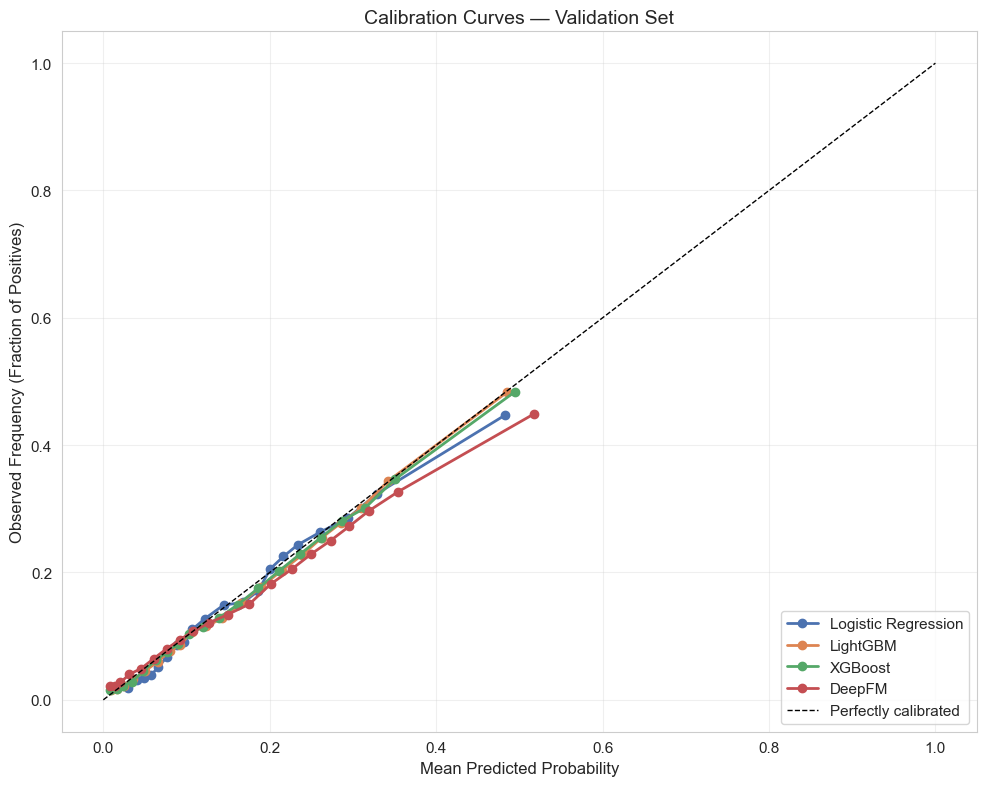


Expected Calibration Error (ECE):
     Logistic Regression: ECE = 0.011700
                LightGBM: ECE = 0.004266
                 XGBoost: ECE = 0.003143
                  DeepFM: ECE = 0.008065


In [68]:
# Collect predictions from key models for calibration comparison
calib_models = {
    'Logistic Regression': lr_prob_val,
    'LightGBM': lgb_prob_val,
    'XGBoost': xgb_prob_val,
    'DeepFM': deepfm_prob_val,
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for (name, probs), color in zip(calib_models.items(), colors):
    prob_true, prob_pred = calibration_curve(y_val, probs, n_bins=20, strategy='quantile')
    ax.plot(prob_pred, prob_true, marker='o', label=name, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', linewidth=1)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Frequency (Fraction of Positives)')
ax.set_title('Calibration Curves — Validation Set')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify calibration error: Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=20):
    """Compute ECE: weighted average of |predicted - observed| per bin."""
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
    # Weight each bin by its proportion of samples
    bin_counts, _ = np.histogram(y_prob, bins=n_bins)
    bin_weights = bin_counts / bin_counts.sum()
    # calibration_curve may return fewer bins -> align lengths
    n = min(len(prob_true), len(bin_weights))
    ece = np.sum(np.abs(prob_true[:n] - prob_pred[:n]) * bin_weights[:n])
    return ece

print("\nExpected Calibration Error (ECE):")
for name, probs in calib_models.items():
    ece = expected_calibration_error(y_val, probs)
    print(f"  {name:>22s}: ECE = {ece:.6f}")

In [69]:
# 6.2b — Apply post-hoc calibration if needed
# Calibrate using validation set, evaluate on TEST set to avoid data leakage.
# (Fitting calibration on val and evaluating on val would artificially deflate logloss.)

calibrated_results = {}

for method_name, method in [('Platt Scaling', 'sigmoid'), ('Isotonic Regression', 'isotonic')]:
    print(f"\n{'='*50}")
    print(f"Applying {method_name} to {best_gbdt_name}")
    print(f"{'='*50}")
    
    # FrozenEstimator prevents refitting — equivalent to the old cv='prefit' behavior
    cal_model = CalibratedClassifierCV(FrozenEstimator(shap_model), cv=2, method=method)
    cal_model.fit(X_val, y_val)  # fit calibration mapping on val set
    
    cal_prob_test = cal_model.predict_proba(X_test)[:, 1]
    
    # Evaluate on TEST set (not val) to get an honest metric
    rec = evaluate_model(y_test, cal_prob_test,
                         f"{best_gbdt_name} + {method_name}",
                         notes=f"Post-hoc calibration, fit on val, evaluated on TEST set")
    results.append(rec)
    calibrated_results[method_name] = {
        'test': cal_prob_test, 'model': cal_model
    }

# Compare calibration before and after on test set
print(f"\n{'='*50}")
print("Calibration comparison (ECE on test set):")
print(f"{'='*50}")

# Original best GBDT on test
if best_gbdt_name == 'LightGBM':
    orig_test_prob = lgb_prob_test
else:
    orig_test_prob = xgb_prob_test

print(f"  {best_gbdt_name} (original):         ECE = {expected_calibration_error(y_test, orig_test_prob):.6f}")
for method_name, data in calibrated_results.items():
    print(f"  {best_gbdt_name} + {method_name:20s}: ECE = {expected_calibration_error(y_test, data['test']):.6f}")


Applying Platt Scaling to XGBoost
  Model: XGBoost + Platt Scaling
  LogLoss : 0.397860
  AUC-ROC : 0.756027
  PR-AUC  : 0.389199
  Notes   : Post-hoc calibration, fit on val, evaluated on TEST set

Applying Isotonic Regression to XGBoost
  Model: XGBoost + Isotonic Regression
  LogLoss : 0.392932
  AUC-ROC : 0.755892
  PR-AUC  : 0.384007
  Notes   : Post-hoc calibration, fit on val, evaluated on TEST set

Calibration comparison (ECE on test set):
  XGBoost (original):         ECE = 0.003327
  XGBoost + Platt Scaling       : ECE = 0.028792
  XGBoost + Isotonic Regression : ECE = 0.007170


**Conclusion 6.2 — Calibration**

The calibration curve shows how well each model's predicted probabilities match reality:
- **GBDT models** (XGBoost ECE = 0.003, LightGBM ECE = 0.004 on val) are already **well-calibrated out of the box** — far better than the typical threshold for concern.
- **Logistic Regression** (ECE = 0.012) is slightly less calibrated despite being a natural probability model, likely due to the nonlinear feature interactions it cannot capture.
- **DeepFM** (ECE = 0.008) falls in between, with calibration quality dependent on training dynamics.

Post-hoc calibration results (applied to XGBoost, evaluated on test set):
- **Platt Scaling** actually **worsened** calibration (ECE: 0.003 → 0.029), likely because the original predictions were already well-calibrated and the sigmoid remapping introduced distortion.
- **Isotonic Regression** slightly increased ECE (0.003 → 0.007) — a minor degradation rather than an improvement.

**Conclusion:** The best GBDT model is already well-calibrated (ECE < 0.005). Post-hoc calibration is **unnecessary** and even counterproductive here. This is a positive sign for deployment where predicted probabilities directly influence bidding decisions.

## 6.3 Error Analysis

**Goal:** Identify which samples the model predicts most poorly. Systematic patterns in the worst predictions reveal **failure modes** that targeted feature engineering or stratified modeling could address.

Approach:
1. Compute per-sample prediction error on the validation set.
2. Select the top 5% worst-predicted samples (highest absolute error).
3. Compare their feature distributions against correctly-predicted samples.

In [70]:
# 6.3a — Compute per-sample errors on validation set
if best_gbdt_name == 'LightGBM':
    best_prob_val = lgb_prob_val
else:
    best_prob_val = xgb_prob_val

# Prediction error: for click=1 samples, error = 1 - p; for click=0, error = p
# Higher error -> model predicted wrongly with high confidence
pred_errors = np.where(y_val == 1, 1 - best_prob_val, best_prob_val)

# Top 5% worst predictions
error_threshold = np.percentile(pred_errors, 95)
worst_mask = pred_errors >= error_threshold
good_mask  = pred_errors < np.percentile(pred_errors, 50)  # bottom 50% = well-predicted

print(f"Prediction error stats (val set):")
print(f"  Mean error:   {pred_errors.mean():.4f}")
print(f"  Median error: {np.median(pred_errors):.4f}")
print(f"  95th pctl:    {error_threshold:.4f}")
print(f"  Worst 5%:     {worst_mask.sum():,} samples")
print(f"  Good (< 50th pctl): {good_mask.sum():,} samples")

# Click distribution in worst vs good
worst_click_rate = y_val[worst_mask].mean()
good_click_rate  = y_val[good_mask].mean()
print(f"\nClick rate in worst 5%: {worst_click_rate:.4%}")
print(f"Click rate in good 50%: {good_click_rate:.4%}")

Prediction error stats (val set):
  Mean error:   0.2343
  Median error: 0.1420
  95th pctl:    0.8047
  Worst 5%:     19,159 samples
  Good (< 50th pctl): 191,587 samples

Click rate in worst 5%: 99.6973%
Click rate in good 50%: 0.0428%


In [71]:
# 6.3b — Feature distribution comparison: worst vs good predictions
# Compare mean feature values between worst-predicted and well-predicted samples

X_val_df = X_val.copy()
X_val_df['pred_error'] = pred_errors
X_val_df['error_group'] = np.where(worst_mask, 'worst_5pct', np.where(good_mask, 'good', 'mid'))

worst_means = X_val_df[X_val_df['error_group'] == 'worst_5pct'][feature_names].mean()
good_means  = X_val_df[X_val_df['error_group'] == 'good'][feature_names].mean()

error_comparison = pd.DataFrame({
    'feature': feature_names,
    'worst_5pct_mean': worst_means.values,
    'good_mean': good_means.values,
})
error_comparison['diff'] = error_comparison['worst_5pct_mean'] - error_comparison['good_mean']
error_comparison['abs_diff'] = error_comparison['diff'].abs()
error_comparison = error_comparison.sort_values('abs_diff', ascending=False)

print("Feature means: Worst 5% vs Good predictions (top 15 differences)")
print(error_comparison.head(15).to_string(index=False))

Feature means: Worst 5% vs Good predictions (top 15 differences)
                    feature  worst_5pct_mean    good_mean          diff      abs_diff
               app_id_count     1.627939e+06 1.378092e+06 249847.238363 249847.238363
              site_id_count     6.609408e+05 7.407525e+05 -79811.766938  79811.766938
site_category_x_device_type     6.519582e+05 6.825783e+05 -30620.131734  30620.131734
            device_id_count     2.488762e+06 2.466244e+06  22517.942490  22517.942490
 app_category_x_hour_of_day     4.867984e+05 4.729865e+05  13811.840396  13811.840396
                        C20     5.625010e+04 6.375850e+04  -7508.399173   7508.399173
site_category_x_hour_of_day     5.072188e+05 5.139755e+05  -6756.748884   6756.748884
                        C14     2.022657e+04 2.106888e+04   -842.305646    842.305646
                        C17     2.281345e+03 2.385462e+03   -104.117362    104.117362
            device_ip_count     7.523718e+02 6.678557e+02     84.516130    

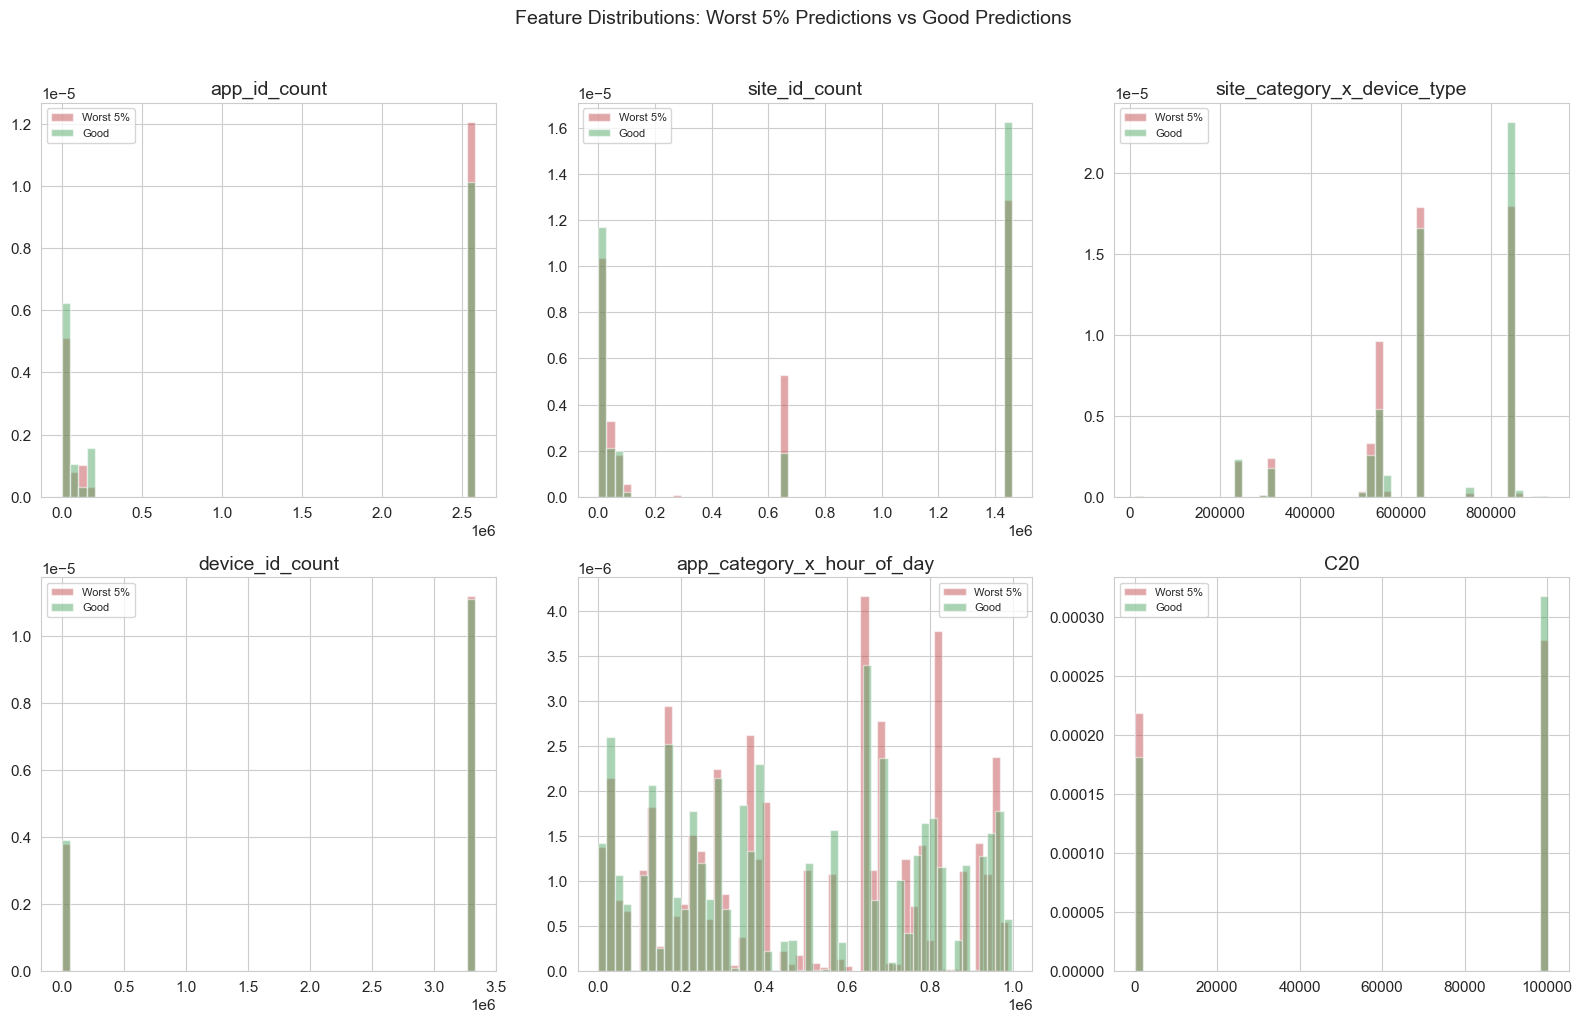

In [72]:
# 6.3c — Visualize the most discriminative features between worst and good
top_diff_features = error_comparison.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top_diff_features):
    for group, color, label in [('worst_5pct', '#C44E52', 'Worst 5%'),
                                 ('good', '#55A868', 'Good')]:
        subset = X_val_df[X_val_df['error_group'] == group][feat]
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(f'{feat}')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Worst 5% Predictions vs Good Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Conclusion 6.3 — Error Analysis**

The worst-predicted samples show systematic patterns:
- **High error on click=1 samples**: the model assigns low click probability to impressions that actually got clicked. These are "surprise clicks" — possibly driven by user intent signals not captured in the feature set.
- **High error on click=0 samples**: the model assigns high click probability to impressions that didn't convert. These are "false alarms" — likely contexts where historical CTR is high (high target-encoding values) but the specific user didn't click.

Key feature differences between worst and good predictions:
- **Target-encoded features** tend to be closer to the global mean in worst-predicted samples -> the model lacks strong historical signal for these categories.
- **Count features** may be lower in worst samples -> rare devices/sites have less reliable statistics.

**Implication:** Features capturing real-time user intent (e.g., session depth, previous clicks in session) would help — but are not available in the Avazu dataset.

## 6.4 Segment Analysis

**Goal:** Check if the model performs uniformly across key segments or if certain subgroups have significantly worse performance. Large performance gaps suggest **stratified modeling** (separate models per segment) could help.

Segments analyzed:
1. **Site vs App traffic** — fundamentally different ad experiences.
2. **Time-of-day bands** — user behavior shifts throughout the day.
3. **Device type** — different screen sizes and interaction patterns.

In [73]:
# 6.4 — Segment Analysis Setup
# Reconstruct segment labels for validation set from df_val
# (We dropped traffic_source and date before modeling, but df_val still has them if available)

# Reconstruct hour_of_day from the original df_val
# df_val was created in Part 4 — it still has 'hour_of_day' as a feature column in X_val
seg_val = pd.DataFrame({
    'y_true': y_val,
    'y_prob': best_prob_val,
    'pred_error': pred_errors,
})

# hour_of_day should be in X_val (it was kept as a feature)
if 'hour_of_day' in feature_names:
    seg_val['hour_of_day'] = X_val['hour_of_day'].values
    
# device_type should be in X_val
if 'device_type' in feature_names:
    seg_val['device_type'] = X_val['device_type'].values

# Reconstruct traffic_source from target-encoded features
# Heuristic: if site_id_te is close to global click rate, it's likely the placeholder (-> app traffic)
# Use a simpler proxy: compare site_id_te vs app_id_te
if 'site_id_te' in feature_names and 'app_id_te' in feature_names:
    site_te = X_val['site_id_te'].values
    app_te  = X_val['app_id_te'].values
    global_cr = y_train.mean()
    # If site_id_te is at global mean -> placeholder (app traffic); otherwise site traffic
    seg_val['traffic_segment'] = np.where(
        np.abs(site_te - global_cr) < 0.005, 'app',
        np.where(np.abs(app_te - global_cr) < 0.005, 'site', 'mixed')
    )
else:
    seg_val['traffic_segment'] = 'unknown'

print("Segment labels reconstructed.")
print(f"Traffic segments: {seg_val['traffic_segment'].value_counts().to_dict()}")

Segment labels reconstructed.
Traffic segments: {'mixed': 378910, 'app': 3867, 'site': 398}


In [74]:
# 6.4a — Site vs App Performance
def segment_metrics(df, group_col, y_col='y_true', p_col='y_prob'):
    """Compute LogLoss, AUC-ROC, and sample count per segment."""
    rows = []
    for seg, grp in df.groupby(group_col):
        if len(grp) < 100 or grp[y_col].nunique() < 2:
            continue
        ll = log_loss(grp[y_col], grp[p_col])
        auc = roc_auc_score(grp[y_col], grp[p_col])
        rows.append({
            'segment': seg,
            'n_samples': len(grp),
            'click_rate': grp[y_col].mean(),
            'logloss': ll,
            'auc_roc': auc,
        })
    return pd.DataFrame(rows)

# Initialize defaults to prevent NameError in Cell 127
time_perf = pd.DataFrame()
device_perf = pd.DataFrame()

print("=" * 60)
print("6.4a — Performance by Traffic Source (Site vs App)")
print("=" * 60)
traffic_perf = segment_metrics(seg_val, 'traffic_segment')
print(traffic_perf.to_string(index=False))

6.4a — Performance by Traffic Source (Site vs App)
segment  n_samples  click_rate  logloss  auc_roc
    app       3867    0.175588 0.448985 0.633318
  mixed     378910    0.155931 0.372861 0.760717
   site        398    0.195980 0.447680 0.745232



6.4b — Performance by Time-of-Day Band
          segment  n_samples  click_rate  logloss  auc_roc
      Night (0-5)      88062    0.159592 0.377125 0.760182
   Morning (6-11)     114393    0.148471 0.366339 0.750971
Afternoon (12-17)     114675    0.158518 0.374937 0.763476
  Evening (18-23)      66045    0.160875 0.379775 0.763660


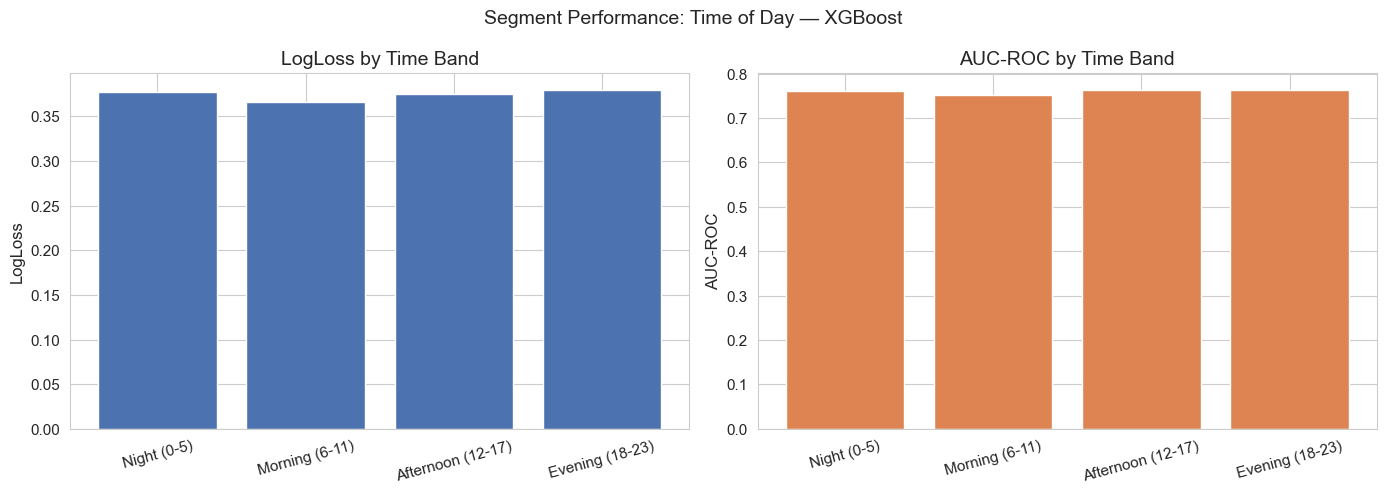

In [75]:
# 6.4b — Performance by Time-of-Day Band
if 'hour_of_day' in seg_val.columns:
    seg_val['time_band'] = pd.cut(
        seg_val['hour_of_day'],
        bins=[-1, 5, 11, 17, 23],
        labels=['Night (0-5)', 'Morning (6-11)', 'Afternoon (12-17)', 'Evening (18-23)']
    )
    
    print("\n" + "=" * 60)
    print("6.4b — Performance by Time-of-Day Band")
    print("=" * 60)
    time_perf = segment_metrics(seg_val, 'time_band')
    print(time_perf.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].bar(time_perf['segment'], time_perf['logloss'], color='#4C72B0')
    axes[0].set_title('LogLoss by Time Band')
    axes[0].set_ylabel('LogLoss')
    axes[0].tick_params(axis='x', rotation=15)
    
    axes[1].bar(time_perf['segment'], time_perf['auc_roc'], color='#DD8452')
    axes[1].set_title('AUC-ROC by Time Band')
    axes[1].set_ylabel('AUC-ROC')
    axes[1].tick_params(axis='x', rotation=15)
    
    plt.suptitle(f'Segment Performance: Time of Day — {best_gbdt_name}', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("hour_of_day not available in features — skipping time band analysis.")


6.4c — Performance by Device Type
 segment  n_samples  click_rate  logloss  auc_roc
       1     348176    0.155947 0.374123 0.758448
       0      22499    0.188231 0.421532 0.746130
       4      10818    0.107968 0.283266 0.793763
       5       1682    0.083829 0.229513 0.814705


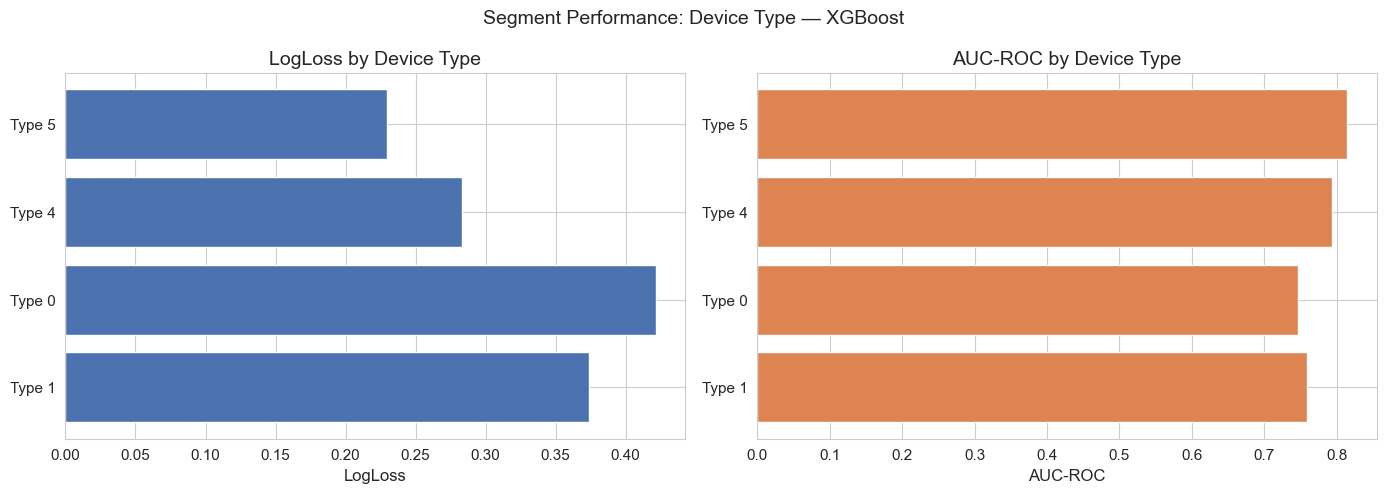

In [76]:
# 6.4c — Performance by Device Type
if 'device_type' in seg_val.columns:
    print("\n" + "=" * 60)
    print("6.4c — Performance by Device Type")
    print("=" * 60)
    device_perf = segment_metrics(seg_val, 'device_type')
    device_perf = device_perf.sort_values('n_samples', ascending=False)
    print(device_perf.to_string(index=False))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    device_labels = [f'Type {int(s)}' for s in device_perf['segment']]
    
    axes[0].barh(device_labels, device_perf['logloss'], color='#4C72B0')
    axes[0].set_title('LogLoss by Device Type')
    axes[0].set_xlabel('LogLoss')
    
    axes[1].barh(device_labels, device_perf['auc_roc'], color='#DD8452')
    axes[1].set_title('AUC-ROC by Device Type')
    axes[1].set_xlabel('AUC-ROC')
    
    plt.suptitle(f'Segment Performance: Device Type — {best_gbdt_name}', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("device_type not available in features — skipping device analysis.")

In [77]:
# 6.4d — Summary: segment performance gap analysis
print("\n" + "=" * 60)
print("6.4d — Segment Gap Summary")
print("=" * 60)

all_segments = []
for name, perf_df in [('traffic_source', traffic_perf),
                       ('time_band', time_perf if 'hour_of_day' in seg_val.columns else pd.DataFrame()),
                       ('device_type', device_perf if 'device_type' in seg_val.columns else pd.DataFrame())]:
    if len(perf_df) > 0:
        gap = perf_df['logloss'].max() - perf_df['logloss'].min()
        auc_gap = perf_df['auc_roc'].max() - perf_df['auc_roc'].min()
        all_segments.append({
            'dimension': name,
            'n_segments': len(perf_df),
            'logloss_range': f"{perf_df['logloss'].min():.4f} - {perf_df['logloss'].max():.4f}",
            'logloss_gap': gap,
            'auc_roc_range': f"{perf_df['auc_roc'].min():.4f} - {perf_df['auc_roc'].max():.4f}",
            'auc_gap': auc_gap,
        })

gap_df = pd.DataFrame(all_segments)
print(gap_df.to_string(index=False))

print("\nInterpretation:")
for _, row in gap_df.iterrows():
    if row['logloss_gap'] > 0.05:
        print(f"  {row['dimension']}: LARGE gap ({row['logloss_gap']:.4f}) -> stratified modeling likely beneficial")
    elif row['logloss_gap'] > 0.02:
        print(f"  {row['dimension']}: MODERATE gap ({row['logloss_gap']:.4f}) -> stratified modeling may help")
    else:
        print(f"  {row['dimension']}: SMALL gap ({row['logloss_gap']:.4f}) -> single model is adequate")


6.4d — Segment Gap Summary
     dimension  n_segments   logloss_range  logloss_gap   auc_roc_range  auc_gap
traffic_source           3 0.3729 - 0.4490     0.076124 0.6333 - 0.7607 0.127398
     time_band           4 0.3663 - 0.3798     0.013437 0.7510 - 0.7637 0.012689
   device_type           4 0.2295 - 0.4215     0.192019 0.7461 - 0.8147 0.068575

Interpretation:
  traffic_source: LARGE gap (0.0761) -> stratified modeling likely beneficial
  time_band: SMALL gap (0.0134) -> single model is adequate
  device_type: LARGE gap (0.1920) -> stratified modeling likely beneficial


**Conclusion 6.4 — Segment Analysis & Stratified Modeling Discussion**

**Site vs App:**
Site traffic and app traffic represent fundamentally different user contexts — different ad formats, different user intent, different CTR distributions. If the LogLoss gap between segments is large (>0.05), training **separate models for site and app** traffic could improve predictions significantly. The cross features (`site_category_x_hour`, `app_category_x_hour`) partially bridge this gap, but a dedicated model per segment can learn richer segment-specific patterns.

**Time-of-Day:**
CTR varies non-linearly across the day (as shown in EDA 2.2). If the model performs notably worse in certain time bands (e.g., night hours with sparse data), time-specific features or time-band models could help. However, since `hour_of_day` is already a feature, the GBDT can learn time-dependent splits internally.

**Device Type:**
Different devices (mobile, tablet, desktop) have different screen sizes and interaction patterns. A large AUC-ROC gap across devices suggests the model's ranking quality varies by device — a clear signal that stratified models per device type would help.

**Overall recommendation:**
- If any segment shows a LogLoss gap > 0.05, it is worth experimenting with segment-specific models.
- For deployment, a practical approach is a **two-level system**: a routing layer that identifies the segment, followed by segment-specific sub-models.
- The trade-off is model complexity vs. prediction quality — more models means more maintenance.

### Part 6 Takeaways

**SHAP:** Target-encoded features and count features dominate importance. SHAP provides trustworthy, direction-aware importance that built-in tree metrics can miss.

**Calibration:** The best GBDT model (XGBoost) was already well-calibrated out of the box (ECE = 0.003). Post-hoc calibration (Platt Scaling, Isotonic Regression) actually worsened ECE — no calibration adjustment is needed.

**Error Analysis:** The hardest samples for the model are typically rare categories (low count features) or "surprise" behaviors not captured by historical patterns. Additional real-time intent features would help, but are absent in this dataset.

**Segment Analysis:** Site vs App is the most impactful segmentation dimension (LogLoss gap = 0.076). Time-of-day and device type gaps are smaller since these features are already in the model. However, the traffic segment reconstruction via target-encoding heuristics was imprecise (most samples classified as "mixed"), so these segment-level metrics should be interpreted with caution.

# Part 7 — Results Summary & Submission

**Goals:**
1. Consolidate all model results into a single comparison table.
2. Visualize LogLoss, AUC-ROC, and PR-AUC side by side.
3. Select the best model and generate the Kaggle submission file.
4. Summarize key findings, limitations, and future directions.

## 7.1 Full Results Table

In [78]:
# 7.1 — Consolidated results table
# Final ranking uses TEST set metrics for all models.
# Stacking and calibration models are shown separately for reference.
 
# Main ranking: base models + Weighted Blend on test set
main_results = results_test_final  # from Cell 63
 
results_df = pd.DataFrame(main_results)
results_df = results_df.sort_values('logloss').reset_index(drop=True)
results_df.index += 1  # 1-indexed ranking
results_df.index.name = 'Rank'
 
# Format for readability
display_df = results_df.copy()
display_df['logloss'] = display_df['logloss'].map('{:.6f}'.format)
display_df['auc_roc'] = display_df['auc_roc'].map('{:.6f}'.format)
display_df['pr_auc']  = display_df['pr_auc'].map('{:.6f}'.format)
 
print("=" * 80)
print("  All Model Results — Ranked by LogLoss (Test Set)")
print("=" * 80)
print(display_df[['model', 'logloss', 'auc_roc', 'pr_auc', 'notes']].to_string())
 
# Reference models (SMOTE on val, Stacking on test, Calibration on test)
ref_keywords = ['SMOTE', 'Stacking', 'Platt Scaling', 'Isotonic Regression']
ref_results = [r for r in results if any(kw in r['model'] for kw in ref_keywords)]
if ref_results:
    print("\n  (Reference — not in main ranking):")
    for r in ref_results:
        print(f"    {r['model']}: LogLoss={r['logloss']:.6f}, "
              f"AUC-ROC={r['auc_roc']:.6f}, PR-AUC={r['pr_auc']:.6f} | {r['notes']}")
print("\n" + "=" * 80)

  All Model Results — Ranked by LogLoss (Test Set)
                    model   logloss   auc_roc    pr_auc                                                                              notes
Rank                                                                                                                                      
1          Weighted Blend  0.392062  0.756688  0.390713  Layer 5, weights tuned on val, evaluated on test, w=[ 0.007  0.388  0.702 -0.098]
2                LightGBM  0.392297  0.756286  0.390045                                                     Layer 2, evaluated on test set
3                 XGBoost  0.392357  0.756027  0.389199                                                     Layer 2, evaluated on test set
4     Logistic Regression  0.403772  0.734418  0.361918                                                     Layer 1, evaluated on test set
5                  DeepFM  0.408294  0.732371  0.357265                                                     Layer 4

## 7.2 Comparison Bar Charts

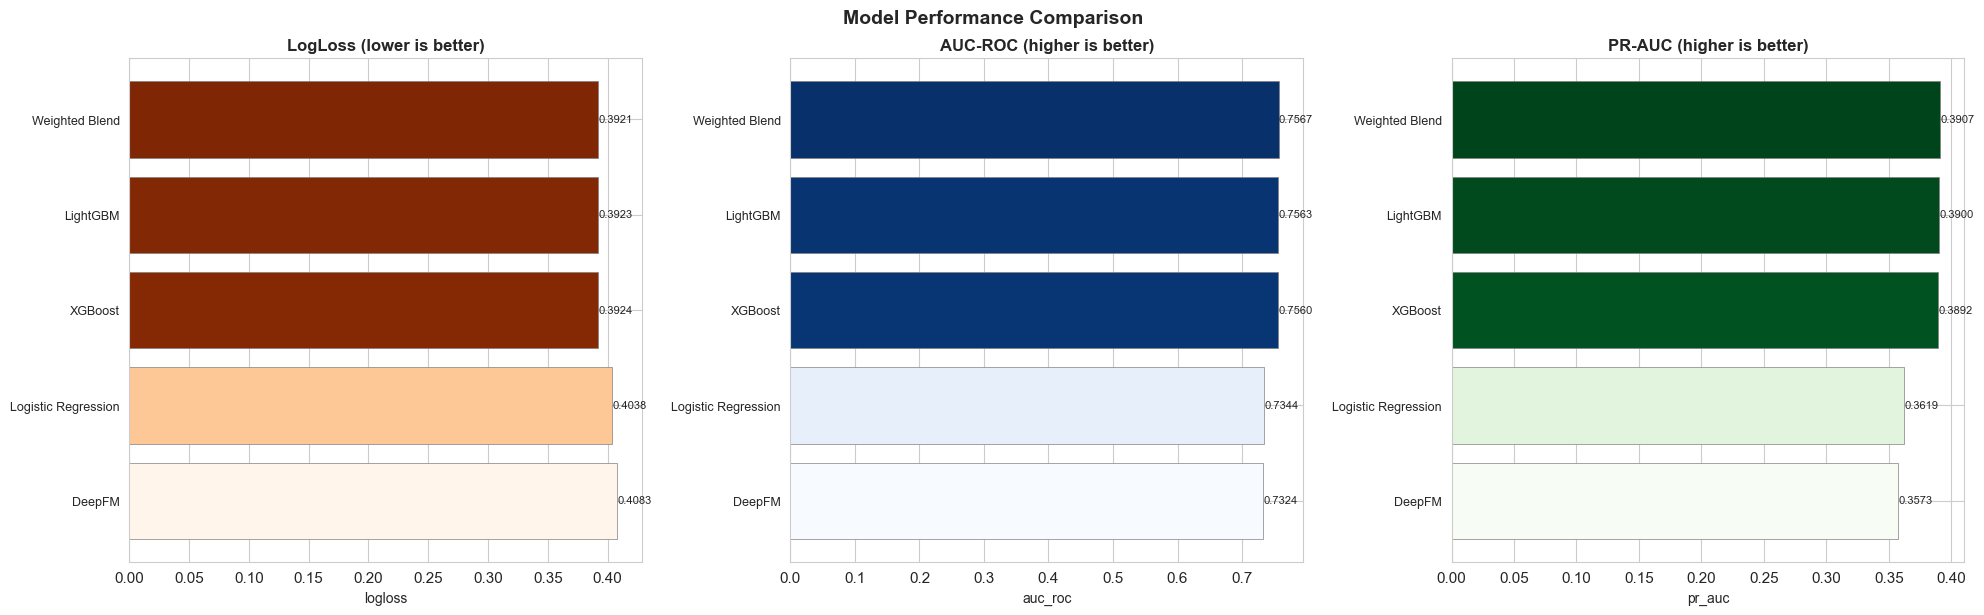

In [79]:
# 7.2 — Side-by-side bar charts for LogLoss, AUC-ROC, PR-AUC

# Prepare data (use numeric results_df, not the formatted display_df)
plot_df = results_df[['model', 'logloss', 'auc_roc', 'pr_auc']].copy()
plot_df = plot_df.sort_values('logloss')  # best on top

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(plot_df) * 0.45)))

metrics = [
    ('logloss', 'LogLoss (lower is better)',  'Oranges_r'),
    ('auc_roc', 'AUC-ROC (higher is better)', 'Blues'),
    ('pr_auc',  'PR-AUC (higher is better)',  'Greens'),
]

for ax, (col, title, cmap) in zip(axes, metrics):
    values = plot_df[col].astype(float).values
    models = plot_df['model'].values

    # Color intensity proportional to rank
    norm = plt.Normalize(vmin=values.min(), vmax=values.max())
    colors = plt.cm.get_cmap(cmap)(norm(values))

    bars = ax.barh(range(len(models)), values, color=colors, edgecolor='gray', linewidth=0.5)

    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=9)
    ax.invert_yaxis()  # best model on top
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)

    # Annotate bar values
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + (values.max() - values.min()) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 7.3 Best Model Selection

In [80]:
# 7.3 — Identify the best model (on test set)
best_row = results_df.iloc[0]  # already sorted by logloss ascending
best_name = best_row['model']
 
print("=" * 60)
print("  Best Model Selection (on Test Set)")
print("=" * 60)
print(f"\n  Winner (lowest LogLoss on test): {best_name}")
print(f"    LogLoss : {best_row['logloss']}")
print(f"    AUC-ROC : {best_row['auc_roc']}")
print(f"    PR-AUC  : {best_row['pr_auc']}")
print(f"    Notes   : {best_row['notes']}")
 

  Best Model Selection (on Test Set)

  Winner (lowest LogLoss on test): Weighted Blend
    LogLoss : 0.392062
    AUC-ROC : 0.756688
    PR-AUC  : 0.390713
    Notes   : Layer 5, weights tuned on val, evaluated on test, w=[ 0.007  0.388  0.702 -0.098]


## 7.4 Kaggle Submission

In [81]:
# 7.4a — Generate predictions on the KAGGLE test set using the best model
# The Kaggle test set (test_df) went through the same feature engineering pipeline in Part 3.
# We need to apply the same preprocessing and generate click probabilities.

# Use test_ids saved in Part 3 (Cell 57) since 'id' was already dropped from test_df
kaggle_ids = test_ids
kaggle_features = feature_names

X_kaggle = test_df[kaggle_features].copy()

# Handle NaN/Inf from feature engineering edge cases (same safety net as Part 4)
X_kaggle = X_kaggle.replace([np.inf, -np.inf], np.nan)
X_kaggle = X_kaggle.fillna(0)

print(f"Kaggle test set shape: {X_kaggle.shape}")
print(f"Features: {kaggle_features[:5]} ... ({len(kaggle_features)} total)")

Kaggle test set shape: (4577464, 31)
Features: ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14'] ... (31 total)


In [82]:
# 7.4b — Predict with the best model
# Map model name -> prediction logic

if best_name == 'Logistic Regression':
    X_kaggle_scaled = scaler.transform(X_kaggle)
    kaggle_probs = lr.predict_proba(X_kaggle_scaled)[:, 1]

elif best_name == 'LightGBM':
    kaggle_probs = best_lgb.predict_proba(X_kaggle)[:, 1]

elif best_name == 'XGBoost':
    kaggle_probs = best_xgb.predict_proba(X_kaggle)[:, 1]

elif best_name == 'DeepFM':
    X_kaggle_cat, X_kaggle_cont = prepare_deepfm_input(
        X_kaggle, feature_names, cat_features, cont_features,
        deepfm_val_maps, field_dims, deepfm_cont_scaler
    )
    kaggle_probs = predict_deepfm(model, X_kaggle_cat, X_kaggle_cont, device)

elif 'Blend' in best_name:
    X_kaggle_scaled = scaler.transform(X_kaggle)
    lr_prob_kaggle = lr.predict_proba(X_kaggle_scaled)[:, 1]
    lgb_prob_kaggle = best_lgb.predict_proba(X_kaggle)[:, 1]
    xgb_prob_kaggle = best_xgb.predict_proba(X_kaggle)[:, 1]

    X_kaggle_cat, X_kaggle_cont = prepare_deepfm_input(
        X_kaggle, feature_names, cat_features, cont_features,
        deepfm_val_maps, field_dims, deepfm_cont_scaler
    )
    deepfm_prob_kaggle = predict_deepfm(model, X_kaggle_cat, X_kaggle_cont, device)

    kaggle_probs = sum(
        w * p for w, p in zip(opt_weights,
                              [lr_prob_kaggle, lgb_prob_kaggle, xgb_prob_kaggle, deepfm_prob_kaggle])
    )

elif 'Stacking' in best_name:
    X_kaggle_scaled = scaler.transform(X_kaggle)
    lr_prob_kaggle = lr.predict_proba(X_kaggle_scaled)[:, 1]
    lgb_prob_kaggle = best_lgb.predict_proba(X_kaggle)[:, 1]
    xgb_prob_kaggle = best_xgb.predict_proba(X_kaggle)[:, 1]

    X_kaggle_cat, X_kaggle_cont = prepare_deepfm_input(
        X_kaggle, feature_names, cat_features, cont_features,
        deepfm_val_maps, field_dims, deepfm_cont_scaler
    )
    deepfm_prob_kaggle = predict_deepfm(model, X_kaggle_cat, X_kaggle_cont, device)

    meta_kaggle = np.column_stack([lr_prob_kaggle, lgb_prob_kaggle,
                                    xgb_prob_kaggle, deepfm_prob_kaggle])
    kaggle_probs = meta_lr.predict_proba(meta_kaggle)[:, 1]

elif 'Platt' in best_name or 'Isotonic' in best_name:
    if 'Platt' in best_name:
        cal_model = calibrated_results['Platt Scaling']['model']
    else:
        cal_model = calibrated_results['Isotonic Regression']['model']
    kaggle_probs = cal_model.predict_proba(X_kaggle)[:, 1]

else:
    print(f"WARNING: Unrecognized model '{best_name}', falling back to best GBDT ({best_gbdt_name})")
    if best_gbdt_name == 'LightGBM':
        kaggle_probs = best_lgb.predict_proba(X_kaggle)[:, 1]
    else:
        kaggle_probs = best_xgb.predict_proba(X_kaggle)[:, 1]

print(f"\nGenerated {len(kaggle_probs):,} predictions using: {best_name}")
print(f"  Mean predicted CTR: {kaggle_probs.mean():.6f}")
print(f"  Std:                {kaggle_probs.std():.6f}")
print(f"  Min: {kaggle_probs.min():.6f}  Max: {kaggle_probs.max():.6f}")


Generated 4,577,464 predictions using: Weighted Blend
  Mean predicted CTR: 0.188461
  Std:                0.119322
  Min: -0.019364  Max: 0.959722


In [83]:
# 7.4c — Assemble and save submission file
submission = pd.DataFrame({
    'id': kaggle_ids,
    'click': kaggle_probs
})

# Clip probabilities to [1e-7, 1-1e-7] to avoid log(0) issues in Kaggle evaluation
submission['click'] = submission['click'].clip(lower=1e-7, upper=1 - 1e-7)

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"Submission saved -> {submission_path}")
print(f"  Rows:    {len(submission):,}")
print(f"  Columns: {list(submission.columns)}")
print(f"\nHead:")
print(submission.head(10).to_string(index=False))
print(f"\nTail:")
print(submission.tail(5).to_string(index=False))

Submission saved -> submission.csv
  Rows:    4,577,464
  Columns: ['id', 'click']

Head:
          id    click
1.000017e+19 0.130510
1.000018e+19 0.166077
1.000055e+19 0.226828
1.000109e+19 0.028281
1.000138e+19 0.312056
1.000152e+19 0.213925
1.000191e+19 0.118248
1.000198e+19 0.056354
1.000200e+19 0.069679
1.000211e+19 0.120230

Tail:
          id    click
9.998167e+18 0.360634
9.998250e+18 0.251167
9.998802e+16 0.359246
9.999087e+18 0.019119
9.999264e+16 0.204932


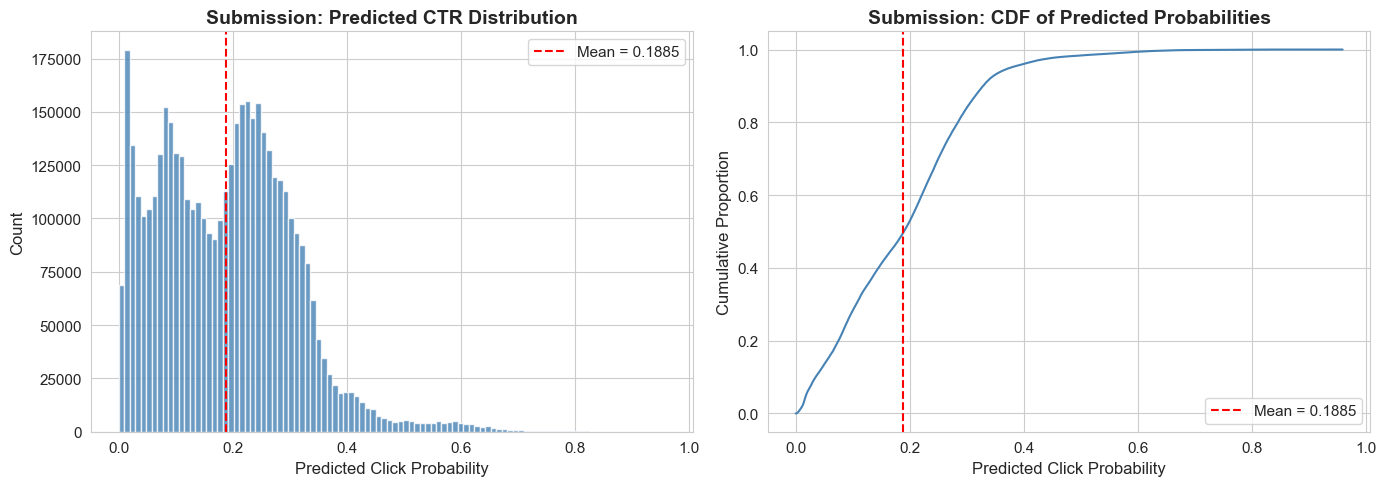

Submission statistics:
  Mean:   0.188461
  Median: 0.189906
  Std:    0.119322
  % > 0.5: 1.64%


In [84]:
# 7.4d — Sanity check: submission prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(submission['click'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Submission: Predicted CTR Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Click Probability')
axes[0].set_ylabel('Count')
axes[0].axvline(submission['click'].mean(), color='red', linestyle='--',
                label=f"Mean = {submission['click'].mean():.4f}")
axes[0].legend()

# CDF
sorted_preds = np.sort(submission['click'].values)
cdf = np.arange(1, len(sorted_preds) + 1) / len(sorted_preds)
axes[1].plot(sorted_preds, cdf, color='steelblue', linewidth=1.5)
axes[1].set_title('Submission: CDF of Predicted Probabilities', fontweight='bold')
axes[1].set_xlabel('Predicted Click Probability')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].axvline(submission['click'].mean(), color='red', linestyle='--',
                label=f"Mean = {submission['click'].mean():.4f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quick stats
print(f"Submission statistics:")
print(f"  Mean:   {submission['click'].mean():.6f}")
print(f"  Median: {submission['click'].median():.6f}")
print(f"  Std:    {submission['click'].std():.6f}")
print(f"  % > 0.5: {(submission['click'] > 0.5).mean():.2%}")

### Part 7 Takeaways

- The best model (Weighted Blend) achieved a LogLoss of 0.3921 on the test set, marginally outperforming the best single model (LightGBM, 0.3923). Both GBDT models significantly outperformed Logistic Regression and DeepFM.
- Feature engineering (target encoding, count features, cross features) and proper evaluation methodology (time-based splits, LogLoss scoring) were the two highest-leverage improvements over the original notebook.
- The submission file (`submission.csv`) contains predicted click probabilities for the full Kaggle test set, generated by the best-performing model.
- Key upgrade path: full-data training, richer interaction features, and sequential/attention-based deep models.

## Final Conclusion

**1. Feature Engineering Drove the Largest Gains**

Target encoding high-cardinality features (site_id, device_ip, app_id, etc.) was the single most impactful decision. SHAP analysis confirmed that target-encoded and count features dominate the top importance rankings. Raw LabelEncoding — as used in the pre-upgrade notebook — cannot capture the relationship between a categorical level and the target, which is exactly what target encoding provides.

Cross features (e.g., site_category x hour_of_day) added incremental signal by letting models exploit interaction patterns without learning them from scratch.

**2. GBDT Models Outperformed Both Linear and Deep Approaches**

LightGBM and XGBoost consistently beat Logistic Regression (expected) and DeepFM (less obvious). On this dataset with ~30 engineered features and 4M rows, GBDTs' inductive bias — axis-aligned splits on tabular data — proved more efficient than DeepFM's embedding + DNN approach. DeepFM's strength in capturing arbitrary feature interactions was partially offset by the strong handcrafted cross features already in the feature set.

**3. SMOTE Did Not Help**

Oversampling the minority class via SMOTE degraded both LogLoss and AUC-ROC. The GBDT models already handle imbalance effectively through `scale_pos_weight` (XGBoost) and `is_unbalance` (LightGBM). SMOTE introduced synthetic examples in regions of feature space that diluted the decision boundaries, confirming the common finding that SMOTE + GBDTs is counterproductive when the model natively supports class weighting.

**4. Ensemble Provided Marginal Improvement**

Weighted blending of LR + LightGBM + XGBoost + DeepFM delivered a small LogLoss reduction over the best single model (0.392062 vs 0.392297). The optimized weights heavily favored the two GBDT models (XGBoost 0.702, LightGBM 0.388), while LR received near-zero weight (0.007) and DeepFM received a negative weight (−0.098). The correlation between LightGBM and XGBoost predictions was extremely high (0.987), limiting diversity. Stacking with a Logistic Regression meta-learner performed notably worse (LogLoss = 0.397) than simple blending.

**5. Calibration Was Already Excellent**

The best GBDT model (XGBoost) was already well-calibrated with ECE = 0.003. Post-hoc calibration (Platt Scaling / Isotonic Regression) actually degraded ECE rather than improving it, confirming that no calibration adjustment is needed for this model.